# Cause degli incidenti stradali gravi in Italia, dati ISTAT 2007-2024

Obiettivo: identificare le circostanze associate al maggior numero di incidenti e alla maggiore mortalita, mantenendo distinte le vittime per categoria di utente della strada: conducenti, persone trasportate e pedoni.

**Nota metodologica importante.** I dati sono aggregati per causa e anno: l'analisi stima associazioni e profili di rischio, non causalita individuale. Per questo, oltre alla regressione lineare richiesta, il notebook usa anche modelli per conteggi, piu adatti a incidenti e decessi.

## 1. Setup

Se mancano librerie nell'ambiente, eseguire una volta:

```python
%pip install pandas numpy matplotlib seaborn scikit-learn statsmodels openpyxl
```

In [126]:
import pandas as pd

# Dice a Pandas di mostrare TUTTE le colonne senza mettere i tre puntini al centro
pd.set_option('display.max_columns', None)

# Dice a Pandas di mostrare TUTTE le righe (occhio se il dataset è gigante, metti es. 100)
pd.set_option('display.max_rows', 10)

# Dice a Pandas di non troncare il testo dentro le celle se è troppo lungo
pd.set_option('display.max_colwidth', None)

In [127]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except Exception:
    sns = None

pd.options.display.float_format = '{:,.2f}'.format
DATA_DIR = Path('.')
if not (DATA_DIR / 'istat_incidenti_cause_2007_2024_wide.csv').exists():
    DATA_DIR = Path(r'C:\Users\Giuseppe Hares\Documents\Codex\2026-06-14\files-mentioned-by-the-user-2024\outputs')
wide_file = DATA_DIR / 'istat_incidenti_cause_2007_2024_wide.csv'
long_file = DATA_DIR / 'istat_incidenti_cause_2007_2024_long.csv'

df = pd.read_csv(wide_file)
df_long = pd.read_csv(long_file)
df.head()

,anno,foglio,causa,tipo_riga,incidenti,morti_conducenti,feriti_conducenti,morti_trasportati,feriti_trasportati,morti_pedoni,feriti_pedoni,morti_totale,feriti_totale,macro_categoria,vittime_totale,morti_utenti_vulnerabili,feriti_utenti_vulnerabili,mortalita_per_1000_incidenti,feriti_per_1000_incidenti,letalita_su_vittime_pct,quota_morti_pedoni_pct,quota_feriti_pedoni_pct,quota_morti_conducenti_pct,quota_morti_trasportati_pct,incidenti_anno_totale,morti_anno_totale,feriti_anno_totale,quota_incidenti_anno_pct,quota_morti_anno_pct,quota_feriti_anno_pct
0,2007,Tav_2.14,Circostanze riferibili al conducente per comportamento nella circolazione,macro_categoria,"149,596.00","1,912.00","151,914.00",449.00,"51,224.00",248.00,"9,601.00","2,609.00","212,739.00",Circostanze riferibili al conducente per comportamento nella circolazione,"215,348.00",248.00,"9,601.00",17.44,"1,422.09",1.21,9.51,4.51,73.28,17.21,"230,871.00","5,131.00","325,850.00",64.80,50.85,65.29
1,2007,Tav_2.14,Procedeva con guida distratta o andamento indeciso,causa_specifica,"24,725.00",416.00,"25,532.00",91.00,"8,493.00",21.00,239.00,528.00,"34,264.00",Circostanze riferibili al conducente per comportamento nella circolazione,"34,792.00",21.00,239.00,21.35,"1,385.80",1.52,3.98,0.70,78.79,17.23,"230,871.00","5,131.00","325,850.00",10.71,10.29,10.52
2,2007,Tav_2.14,senza mantenere la distanza di sicurezza,causa_specifica,"24,713.00",162.00,"26,926.00",51.00,"11,130.00",3.00,279.00,216.00,"38,335.00",Circostanze riferibili al conducente per comportamento nella circolazione,"38,551.00",3.00,279.00,8.74,"1,551.21",0.56,1.39,0.73,75.00,23.61,"230,871.00","5,131.00","325,850.00",10.70,4.21,11.76
3,2007,Tav_2.14,senza dare la precedenza al veicolo proveniente da destra,causa_specifica,"11,970.00",100.00,"12,756.00",8.00,"3,950.00",1.00,38.00,109.00,"16,744.00",Circostanze riferibili al conducente per comportamento nella circolazione,"16,853.00",1.00,38.00,9.11,"1,398.83",0.65,0.92,0.23,91.74,7.34,"230,871.00","5,131.00","325,850.00",5.18,2.12,5.14
4,2007,Tav_2.14,senza rispettare lo stop,causa_specifica,"13,345.00",109.00,"14,529.00",20.00,"4,684.00",0.00,57.00,129.00,"19,270.00",Circostanze riferibili al conducente per comportamento nella circolazione,"19,399.00",0.00,57.00,9.67,"1,443.99",0.66,0.00,0.30,84.50,15.50,"230,871.00","5,131.00","325,850.00",5.78,2.51,5.91


Questa è solo la testa del file

## 2. Struttura dei dati

Il dataset `wide` conserva tutte le colonne originali importanti: morti e feriti per conducenti, persone trasportate e pedoni. Il dataset `long` serve invece per grafici e modelli in cui la categoria dell'utente colpito e una variabile esplicita.

In [128]:
print(df.shape)
display(df[['anno','causa','tipo_riga','macro_categoria','incidenti','morti_conducenti','morti_trasportati','morti_pedoni','morti_totale','feriti_totale']].head(10))
display(df_long.head(12))
df[['incidenti','morti_totale','feriti_totale','mortalita_per_1000_incidenti','quota_morti_pedoni_pct']].describe()

(1149, 30)


,anno,causa,tipo_riga,macro_categoria,incidenti,morti_conducenti,morti_trasportati,morti_pedoni,morti_totale,feriti_totale
0,2007,Circostanze riferibili al conducente per comportamento nella circolazione,macro_categoria,Circostanze riferibili al conducente per comportamento nella circolazione,"149,596.00","1,912.00",449.00,248.00,"2,609.00","212,739.00"
1,2007,Procedeva con guida distratta o andamento indeciso,causa_specifica,Circostanze riferibili al conducente per comportamento nella circolazione,"24,725.00",416.00,91.00,21.00,528.00,"34,264.00"
2,2007,senza mantenere la distanza di sicurezza,causa_specifica,Circostanze riferibili al conducente per comportamento nella circolazione,"24,713.00",162.00,51.00,3.00,216.00,"38,335.00"
3,2007,senza dare la precedenza al veicolo proveniente da destra,causa_specifica,Circostanze riferibili al conducente per comportamento nella circolazione,"11,970.00",100.00,8.00,1.00,109.00,"16,744.00"
4,2007,senza rispettare lo stop,causa_specifica,Circostanze riferibili al conducente per comportamento nella circolazione,"13,345.00",109.00,20.00,0.00,129.00,"19,270.00"
5,2007,senza rispettare il segnale di dare precedenza,causa_specifica,Circostanze riferibili al conducente per comportamento nella circolazione,"13,709.00",95.00,8.00,0.00,103.00,"19,135.00"
6,2007,contromano,causa_specifica,Circostanze riferibili al conducente per comportamento nella circolazione,"4,931.00",198.00,35.00,1.00,234.00,"7,879.00"
7,2007,senza rispettare le segnalazioni semaforiche o dell'agente,causa_specifica,Circostanze riferibili al conducente per comportamento nella circolazione,"2,657.00",19.00,5.00,5.00,29.00,"3,828.00"
8,2007,senza rispettare i segnali di divieto di transito o accesso,causa_specifica,Circostanze riferibili al conducente per comportamento nella circolazione,"1,173.00",5.00,0.00,1.00,6.00,"1,517.00"
9,2007,con eccesso di velocità,causa_specifica,Circostanze riferibili al conducente per comportamento nella circolazione,"19,637.00",462.00,180.00,65.00,707.00,"29,805.00"


,anno,foglio,causa,tipo_riga,macro_categoria,incidenti,categoria_utente_colpito,morti,feriti,vittime,mortalita_per_1000_incidenti,feriti_per_1000_incidenti
0,2007,Tav_2.14,Circostanze riferibili al conducente per comportamento nella circolazione,macro_categoria,Circostanze riferibili al conducente per comportamento nella circolazione,"149,596.00",conducente,"1,912.00","151,914.00","153,826.00",12.78,"1,015.50"
1,2007,Tav_2.14,Procedeva con guida distratta o andamento indeciso,causa_specifica,Circostanze riferibili al conducente per comportamento nella circolazione,"24,725.00",conducente,416.00,"25,532.00","25,948.00",16.83,"1,032.64"
2,2007,Tav_2.14,senza mantenere la distanza di sicurezza,causa_specifica,Circostanze riferibili al conducente per comportamento nella circolazione,"24,713.00",conducente,162.00,"26,926.00","27,088.00",6.56,"1,089.55"
3,2007,Tav_2.14,senza dare la precedenza al veicolo proveniente da destra,causa_specifica,Circostanze riferibili al conducente per comportamento nella circolazione,"11,970.00",conducente,100.00,"12,756.00","12,856.00",8.35,"1,065.66"
4,2007,Tav_2.14,senza rispettare lo stop,causa_specifica,Circostanze riferibili al conducente per comportamento nella circolazione,"13,345.00",conducente,109.00,"14,529.00","14,638.00",8.17,"1,088.72"
...,...,...,...,...,...,...,...,...,...,...,...,...
7,2007,Tav_2.14,senza rispettare le segnalazioni semaforiche o dell'agente,causa_specifica,Circostanze riferibili al conducente per comportamento nella circolazione,"2,657.00",conducente,19.00,"2,638.00","2,657.00",7.15,992.85
8,2007,Tav_2.14,senza rispettare i segnali di divieto di transito o accesso,causa_specifica,Circostanze riferibili al conducente per comportamento nella circolazione,"1,173.00",conducente,5.00,"1,201.00","1,206.00",4.26,"1,023.87"
9,2007,Tav_2.14,con eccesso di velocità,causa_specifica,Circostanze riferibili al conducente per comportamento nella circolazione,"19,637.00",conducente,462.00,"19,994.00","20,456.00",23.53,"1,018.18"
10,2007,Tav_2.14,senza rispettare i limiti di velocità,causa_specifica,Circostanze riferibili al conducente per comportamento nella circolazione,851.00,conducente,30.00,821.00,851.00,35.25,964.75


,incidenti,morti_totale,feriti_totale,mortalita_per_1000_incidenti,quota_morti_pedoni_pct
count,"1,149.00","1,149.00","1,149.00","1,149.00","1,149.00"
mean,"7,772.88",145.33,"10,882.79",23.12,25.16
std,"27,343.76",516.48,"38,645.05",40.00,40.10
min,1.00,0.00,1.00,0.00,0.00
25%,184.00,3.00,208.00,8.37,0.00
50%,776.00,13.00,912.00,16.20,0.00
75%,"3,359.00",52.00,"4,269.00",28.77,27.45
max,"230,871.00","5,131.00","325,850.00","1,000.00",100.00


In [129]:
# Controllo di coerenza: il totale morti deve essere la somma delle tre categorie utente.
check = df.assign(diff_morti=df['morti_totale'] - df[['morti_conducenti','morti_trasportati','morti_pedoni']].sum(axis=1),
                  diff_feriti=df['feriti_totale'] - df[['feriti_conducenti','feriti_trasportati','feriti_pedoni']].sum(axis=1))
display(check[['diff_morti','diff_feriti']].abs().describe())
display(check.loc[(check['diff_morti'].abs()>1e-9) | (check['diff_feriti'].abs()>1e-9), ['anno','causa','diff_morti','diff_feriti']].head())

,diff_morti,diff_feriti
count,"1,149.00","1,149.00"
mean,0.00,0.00
std,0.00,0.00
min,0.00,0.00
25%,0.00,0.00
50%,0.00,0.00
75%,0.00,0.00
max,0.00,0.00


,anno,causa,diff_morti,diff_feriti


Analisi, microcause ridondanti

In [130]:
# Vediamo quali cause specifiche compaiono sotto più di una macro_categoria
df_micro = df[df['tipo_riga'] == 'causa_specifica']
duplicati = df_micro.groupby('causa')['macro_categoria'].nunique()
cause_problematiche = duplicati[duplicati > 1].index.tolist()

print("Cause con lo stesso nome in macro-categorie diverse:")
print(cause_problematiche)

Cause con lo stesso nome in macro-categorie diverse:
['Abbagliato', 'Anormale per ebbrezza da alcool', 'Ostacolo accidentale', 'per condizioni morbose in atto', 'per improvviso malore', 'per sonno']


Cella per pulizia di refusi nome e Assegnazione di tag per differenziazione su macro categorie

In [131]:
# --- INIZIO FIX RETROATTIVO TOTALMENTE BLINDATO V3 ---

# STEP 1: Pulizia spazi e correzione refusi storici noti dell'ISTAT
df['causa'] = df['causa'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)
# Correggiamo "sustanze" in "sostanze" per unificare la causa negli anni
df['causa'] = df['causa'].str.replace('sustanze', 'sostanze', case=False)

df['macro_categoria'] = df['macro_categoria'].astype(str).str.strip().str.replace(r'\s+', ' ', regex=True)

# STEP 2: Funzione che applica il tag a TUTTE le cause specifiche per renderle univoche a prescindere
def assegna_tag_univoco(row):
    if row['tipo_riga'] == 'causa_specifica':
        macro = str(row['macro_categoria']).lower()
        
        # Scegliamo il tag in base alla macro-categoria d'appartenenza
        if 'conducente' in macro:
            tag = "[Conducente]"
        elif 'pedon' in macro:
            tag = "[Pedone]"
        elif 'evitati' in macro:
            tag = "[Ostacoli/Evitati]"
        elif 'urtati' in macro:
            tag = "[Ostacoli/Urtati]"
        else:
            # Se la macro-categoria non è chiara, usiamo il nome del foglio ISTAT
            tag = "[Contesto]"
            
        return f"{tag} {row['causa']}"
    
    return row['causa']

# Applichiamo il fix a tappeto
df['causa'] = df.apply(assegna_tag_univoco, axis=1)
# --- FINE FIX RETROATTIVO ---

# VERIFICA FINALE DEI CASI CRITICI
print("\n--- VERIFICA DEI CASI CRITICI (DOPO FIX V3) ---")
print("Sostanze stupefacenti (Dovresti vedere i tag applicati e una sola dicitura corretta):")
print(df[df['causa'].str.contains('sostanze stupefacenti|ingestione', case=False, na=False)]['causa'].unique())

print("\nCondizioni morbose (Dovrebbero essere separate e taggate chiaramente):")
print(df[df['causa'].str.contains('condizioni morbose|in atto', case=False, na=False)]['causa'].unique())


--- VERIFICA DEI CASI CRITICI (DOPO FIX V3) ---
Sostanze stupefacenti (Dovresti vedere i tag applicati e una sola dicitura corretta):
<StringArray>
['[Conducente] per ingestione di sostanze stupefacenti o psicotrope', '[Pedone] per ingestione di sostanze stupefacenti o psicotrope']
Length: 2, dtype: str

Condizioni morbose (Dovrebbero essere separate e taggate chiaramente):
<StringArray>
['[Conducente] per condizioni morbose in atto', '[Pedone] per condizioni morbose in atto']
Length: 2, dtype: str


## 3. EDA Temporale

Qui guardiamo l'evoluzione temporale deu parametri. La riga `Totale` e usata solo per trend generali, non per addestrare modelli sulle cause.

Analisi Temporale: Incidenti, Morti, Morti ogni 1000 e Feriti ogni 1000

,anno,incidenti,morti_totale,feriti_totale,mortalita_per_1000_incidenti,feriti_per_1000_incidenti
84,2007,"230,871.00","5,131.00","325,850.00",22.22,"1,411.39"
171,2008,"218,963.00","4,731.00","310,739.00",21.61,"1,419.14"
233,2009,"215,405.00","4,237.00","307,258.00",19.67,"1,426.42"
294,2010,"211,404.00","4,090.00","302,735.00",19.35,"1,432.02"
355,2011,"205,638.00","3,860.00","292,019.00",18.77,"1,420.06"
...,...,...,...,...,...,...
905,2020,"118,298.00","2,395.00","159,248.00",20.25,"1,346.16"
966,2021,"151,875.00","2,875.00","204,728.00",18.93,"1,348.00"
1026,2022,"165,889.00","3,159.00","223,475.00",19.04,"1,347.14"
1086,2023,"166,525.00","3,039.00","224,634.00",18.25,"1,348.95"


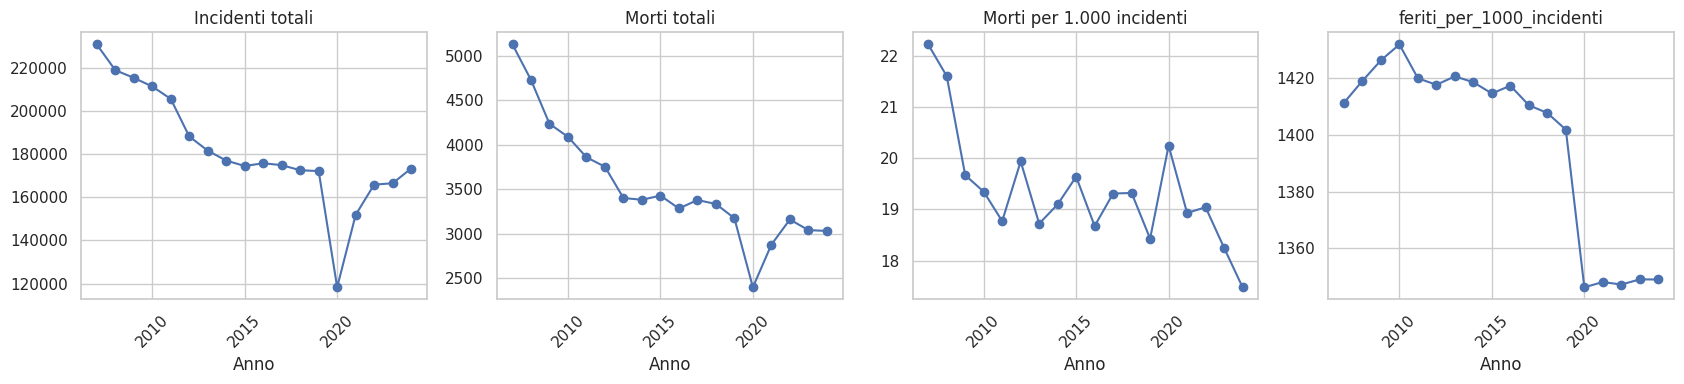

In [132]:
totali = df[df['tipo_riga'].eq('totale')].sort_values('anno')
display(totali[['anno','incidenti','morti_totale','feriti_totale','mortalita_per_1000_incidenti','feriti_per_1000_incidenti']])

fig, axes = plt.subplots(1, 4, figsize=(17,4))
for ax, col, title in zip(axes, ['incidenti','morti_totale','mortalita_per_1000_incidenti','feriti_per_1000_incidenti'], ['Incidenti totali','Morti totali','Morti per 1.000 incidenti','feriti_per_1000_incidenti']):
    ax.plot(totali['anno'], totali[col], marker='o')
    ax.set_title(title)
    ax.set_xlabel('Anno')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Analisi Temporale: Feriti Conducenti, Feriti Trasportati e Feriti Pedoni

,anno,feriti_conducenti,feriti_trasportati,feriti_pedoni
84,2007,"227,326.00","77,999.00","20,525.00"
171,2008,"215,156.00","74,943.00","20,640.00"
233,2009,"213,116.00","73,816.00","20,326.00"
294,2010,"208,071.00","73,297.00","21,367.00"
355,2011,"201,406.00","69,510.00","21,103.00"
...,...,...,...,...
905,2020,"112,598.00","33,103.00","13,547.00"
966,2021,"145,406.00","42,629.00","16,693.00"
1026,2022,"157,430.00","46,983.00","19,062.00"
1086,2023,"157,303.00","47,640.00","19,691.00"


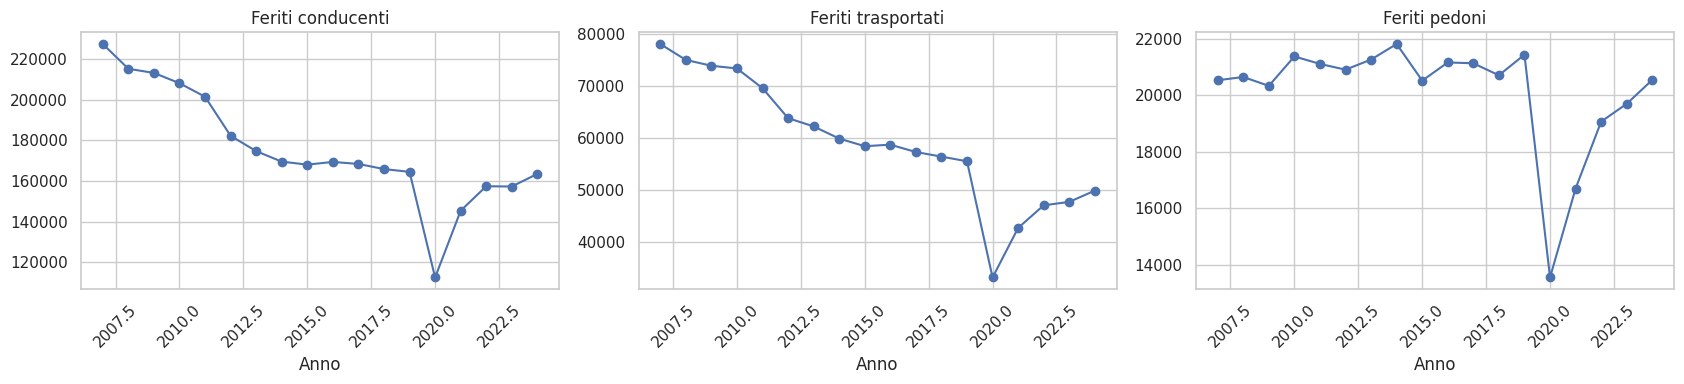

In [133]:
totali = df[df['tipo_riga'].eq('totale')].sort_values('anno')
display(totali[['anno','feriti_conducenti','feriti_trasportati','feriti_pedoni']])

fig, axes = plt.subplots(1, 3, figsize=(17,4))
for ax, col, title in zip(axes, ['feriti_conducenti','feriti_trasportati','feriti_pedoni'], ['Feriti conducenti','Feriti trasportati','Feriti pedoni']):
    ax.plot(totali['anno'], totali[col], marker='o')
    ax.set_title(title)
    ax.set_xlabel('Anno')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Analisi Temporale: Morti Conducenti, Morti Trasportati e Morti Pedoni

,anno,morti_conducenti,morti_trasportati,morti_pedoni
84,2007,"3,645.00",859.00,627.00
171,2008,"3,303.00",780.00,648.00
233,2009,"2,934.00",636.00,667.00
294,2010,"2,837.00",639.00,614.00
355,2011,"2,690.00",581.00,589.00
...,...,...,...,...
905,2020,"1,697.00",289.00,409.00
966,2021,"2,072.00",332.00,471.00
1026,2022,"2,245.00",429.00,485.00
1086,2023,"2,135.00",419.00,485.00


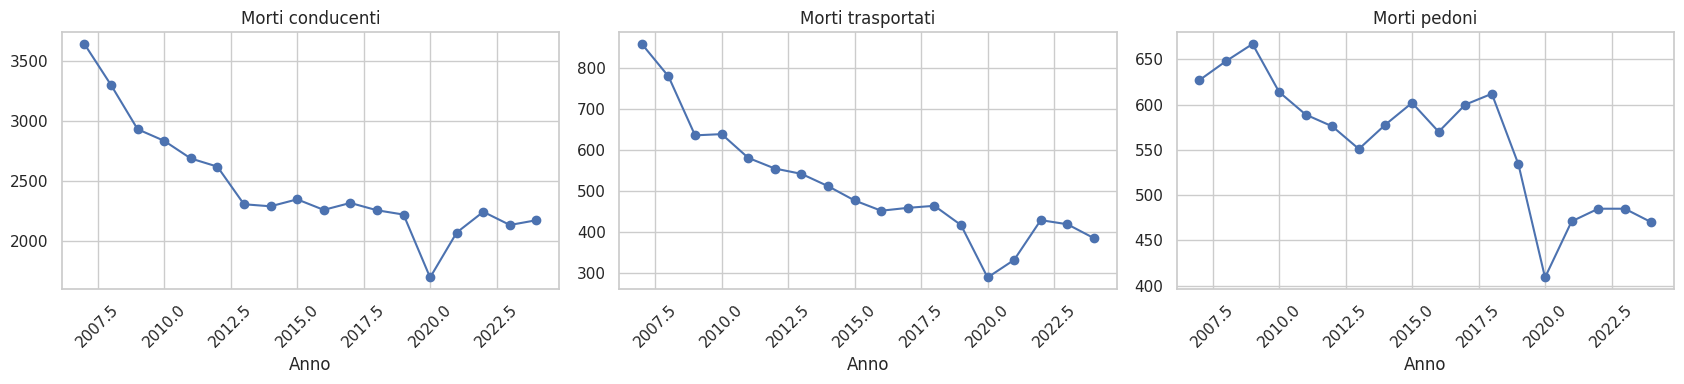

In [134]:
totali = df[df['tipo_riga'].eq('totale')].sort_values('anno')
display(totali[['anno','morti_conducenti','morti_trasportati','morti_pedoni']])

fig, axes = plt.subplots(1, 3, figsize=(17,4))
for ax, col, title in zip(axes, ['morti_conducenti','morti_trasportati','morti_pedoni'], ['Morti conducenti','Morti trasportati','Morti pedoni']):
    ax.plot(totali['anno'], totali[col], marker='o')
    ax.set_title(title)
    ax.set_xlabel('Anno')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4. Cause principali: frequenza e gravita

Una causa puo essere prioritaria perche genera molti incidenti, oppure perche ha pochi incidenti ma una mortalita alta. Per questo calcoliamo entrambi i ranking.

## 4.1 Cause; Ranking Statico

Mortalità pool è il Tasso Aggregato, molto piu utile quando aggrego più anni

*"Al fine di identificare i pattern di rischio senza subire le distorsioni tipiche dei piccoli campioni (micro-cause con pochissimi eventi che generano tassi di mortalità artificialmente vicini a 1000), si è optato per due strategie metodologiche:Il calcolo della mortalita_pool, che aggrega l'intera massa di morti e incidenti del periodo prima di calcolare il tasso, fungendo da media ponderata implicita.Il filtraggio del ranking di letalità attraverso la rimozione del primo quartile delle distribuzioni degli incidenti ($Q_1$), escludendo le code della distribuzione ed evidenziando la pericolosità intrinseca delle sole cause statisticamente rilevanti."*

In [135]:
cause = df[df['tipo_riga'].eq('causa_specifica')].copy()
# Escludo righe residuali solo per alcuni ranking interpretativi; tenerle per audit e possibile analisi separata.
residuali = cause['causa'].str.contains('Altre circostanze|imprecisate|concomitanti', case=False, na=False)
cause_core = cause[~residuali].copy()

ranking = (cause_core.groupby('causa', as_index=False)
           .agg(incidenti=('incidenti','sum'), morti=('morti_totale','sum'), feriti=('feriti_totale','sum'),
                mortalita_media=('mortalita_per_1000_incidenti','mean'), anni_presenti=('anno','nunique'))
           .assign(mortalita_pool=lambda x: x['morti'] / x['incidenti'].replace(0,np.nan) * 1000)
           .sort_values('incidenti', ascending=False))

display(ranking.head(15))
display(ranking.sort_values('morti', ascending=False).head(15))
display(ranking[ranking['incidenti'] >= ranking['incidenti'].quantile(.25)].sort_values('mortalita_pool', ascending=False).head(15))

#ranking per incidenti
#ranking per morti
#ranking per mortalità (solo cause con almeno 25% degli incidenti)



,causa,incidenti,morti,feriti,mortalita_media,anni_presenti,mortalita_pool
9,[Conducente] Procedeva con guida distratta o andamento indeciso,"402,925.00","7,371.00","558,538.00",18.29,18,18.29
33,[Conducente] senza mantenere la distanza di sicurezza,"330,798.00","3,117.00","525,305.00",9.65,18,9.42
21,[Conducente] con eccesso di velocità,"263,869.00","8,120.00","396,342.00",30.52,18,30.77
39,[Conducente] senza rispettare lo stop,"187,042.00","1,273.00","277,010.00",6.74,18,6.81
37,[Conducente] senza rispettare il segnale di dare precedenza,"176,027.00",935.00,"243,598.00",5.18,18,5.31
...,...,...,...,...,...,...,...
18,[Conducente] Svoltava a sinistra irregolarmente,"57,851.00",578.00,"77,745.00",9.79,18,9.99
31,"[Conducente] per svoltare a sinistra (passaggio privato, distributore)","56,638.00",872.00,"76,864.00",15.45,18,15.40
67,[Pedone] Attraversava la strada irregolarmente,"45,997.00","1,410.00","51,784.00",30.74,18,30.65
61,[Ostacoli/Urtati] Ostacolo accidentale,"41,177.00",986.00,"48,359.00",24.32,18,23.95


,causa,incidenti,morti,feriti,mortalita_media,anni_presenti,mortalita_pool
21,[Conducente] con eccesso di velocità,"263,869.00","8,120.00","396,342.00",30.52,18,30.77
9,[Conducente] Procedeva con guida distratta o andamento indeciso,"402,925.00","7,371.00","558,538.00",18.29,18,18.29
23,[Conducente] contromano,"66,350.00","3,344.00","108,448.00",50.24,18,50.40
33,[Conducente] senza mantenere la distanza di sicurezza,"330,798.00","3,117.00","525,305.00",9.65,18,9.42
7,[Conducente] Non dava la precedenza al pedone sugli appositi attraversamenti,"109,631.00","2,261.00","122,498.00",20.74,18,20.62
...,...,...,...,...,...,...,...
37,[Conducente] senza rispettare il segnale di dare precedenza,"176,027.00",935.00,"243,598.00",5.18,18,5.31
31,"[Conducente] per svoltare a sinistra (passaggio privato, distributore)","56,638.00",872.00,"76,864.00",15.45,18,15.40
6,[Conducente] Manovrava in retrocessione o conversione,"58,367.00",845.00,"70,364.00",14.46,18,14.48
10,[Conducente] Procedeva non in prossimità del margine destro della carreggiata,"24,526.00",579.00,"37,577.00",23.52,18,23.61


,causa,incidenti,morti,feriti,mortalita_media,anni_presenti,mortalita_pool
28,[Conducente] per improvviso malore,"1,114.00",212.00,"1,377.00",190.11,2,190.31
30,[Conducente] per sonno,870.00,74.00,"1,403.00",84.71,2,85.06
49,[Contesto] Rottura o insufficienza dei freni,259.00,16.00,405.00,53.19,2,61.78
29,[Conducente] per ingestione di sostanze stupefacenti o psicotrope,"1,025.00",59.00,"1,692.00",57.48,2,57.56
35,[Conducente] senza rispettare i limiti di velocità,"9,581.00",516.00,"14,537.00",56.32,18,53.86
...,...,...,...,...,...,...,...
34,[Conducente] senza osservare l'apposito segnale di divieto,"5,343.00",218.00,"8,456.00",41.25,18,40.80
0,[Conducente] Abbagliato,153.00,6.00,205.00,41.18,2,39.22
69,[Pedone] Camminava in mezzo alla carreggiata,"13,329.00",498.00,"14,575.00",36.95,18,37.36
72,[Pedone] Saliva su veicolo in marcia,443.00,15.00,480.00,29.39,18,33.86


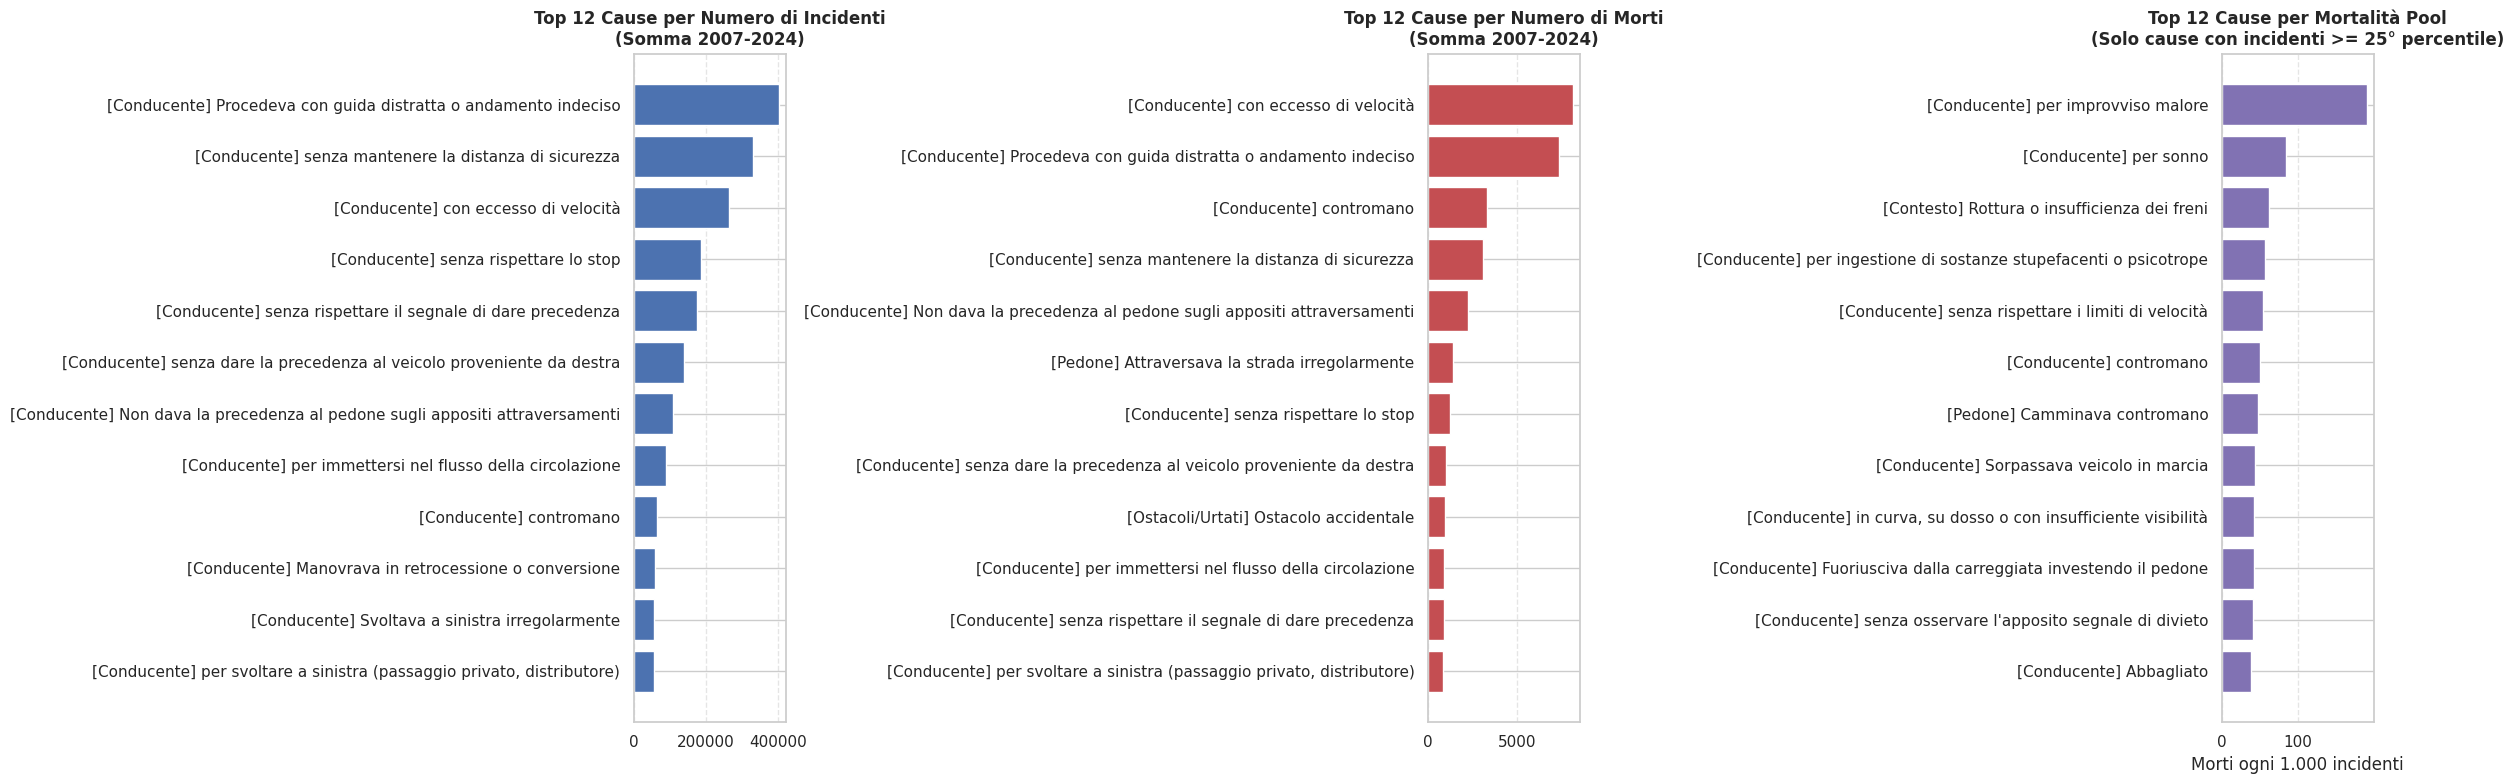

In [136]:
# 1. Estrarre i dati per i primi due grafici (senza filtri di soglia minima)
top_inc = ranking.nlargest(12, 'incidenti').sort_values('incidenti')
top_dead = ranking.nlargest(12, 'morti').sort_values('morti')

# 2. Applicare il filtro del primo quartile (25%) sugli incidenti SOLO per il ranking di mortalità
soglia_25 = ranking['incidenti'].quantile(.25)
ranking_filtrato_mortalita = ranking[ranking['incidenti'] >= soglia_25]

# 3. Estrarre le 12 cause con più mortalità dal dataset pulito dal rumore statistico
top_mortalita = ranking_filtrato_mortalita.nlargest(12, 'mortalita_pool').sort_values('mortalita_pool')

# 4. Generazione dei tre grafici affiancati
fig, axes = plt.subplots(1, 3, figsize=(24, 8)) # Aumentata leggermente l'altezza a 8 per far respirare i testi delle cause

# Grafico 1: Incidenti (Colore Blu/Azzurro)
axes[0].barh(top_inc['causa'], top_inc['incidenti'], color='#4c72b0')
axes[0].set_title('Top 12 Cause per Numero di Incidenti\n(Somma 2007-2024)', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# Grafico 2: Morti (Colore Rosso/Arancio)
axes[1].barh(top_dead['causa'], top_dead['morti'], color='#c44e52')
axes[1].set_title('Top 12 Cause per Numero di Morti\n(Somma 2007-2024)', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

# Grafico 3: Mortalità Pool Filtrata (Colore Viola)
axes[2].barh(top_mortalita['causa'], top_mortalita['mortalita_pool'], color='#8172b3')
axes[2].set_title('Top 12 Cause per Mortalità Pool\n(Solo cause con incidenti >= 25° percentile)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Morti ogni 1.000 incidenti')
axes[2].grid(axis='x', linestyle='--', alpha=0.5)

# Ottimizzazione del layout per evitare che i nomi lunghi delle cause si sovrappongano o vengano tagliati
plt.tight_layout()
plt.show()

## 4.2 Cause; Ranking annuale

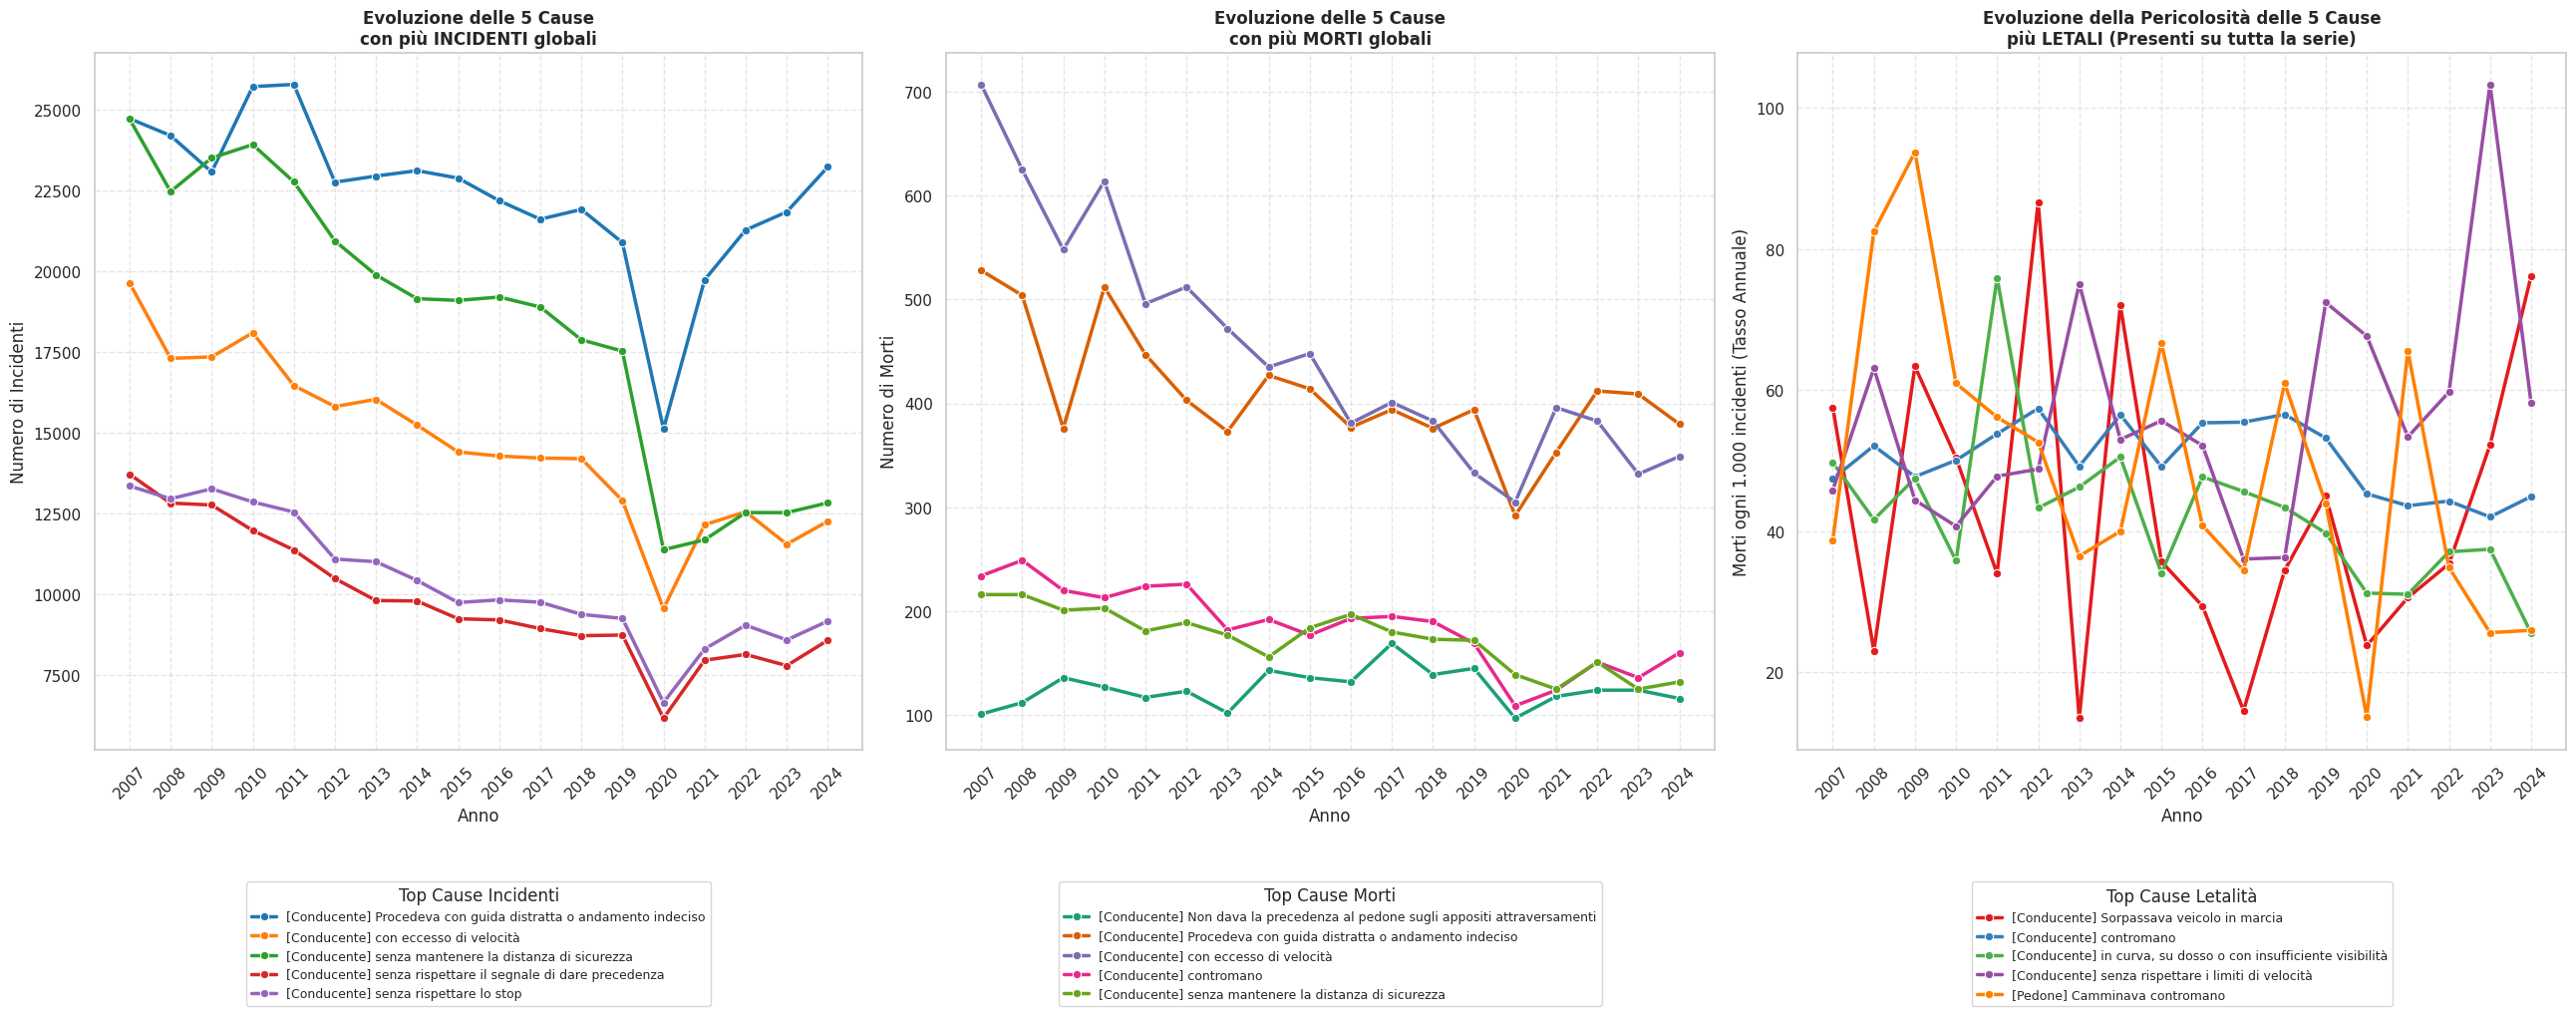

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =====================================================================
# 1. CALCOLO DEI TREND STORICI (Aggregazione annuale corretta)
# =====================================================================
trend_annuale = (cause_core.groupby(['causa', 'anno'], as_index=False)
                 .agg(incidenti=('incidenti', 'sum'), 
                      morti=('morti_totale', 'sum')))

# Chiamiamo la variabile con il suo vero nome annuale, non più "pool"
trend_annuale['mortalita_annuale'] = (trend_annuale['morti'] / 
                                      trend_annuale['incidenti'].replace(0, np.nan) * 1000)

anni_esatti = sorted(trend_annuale['anno'].unique())


# =====================================================================
# 2. SELEZIONE DELLE TOP 5 CON FILTRO DI CONTINUITÀ STORICA
# =====================================================================
top_5_incidenti = ranking.nlargest(5, 'incidenti')['causa'].tolist()
top_5_morti = ranking.sort_values('morti', ascending=False).head(5)['causa'].tolist()

# PER LA LETALITÀ: Applichiamo il doppio filtro (Volume minimo E continuità nel tempo)
soglia_25 = ranking['incidenti'].quantile(.25)
ranking_filtrato = ranking[ranking['incidenti'] >= soglia_25]

# ESCLUSIONE DELLE CAUSE SPARITE: Devono essere presenti in almeno 15 anni su 18
ranking_continuita = ranking_filtrato[ranking_filtrato['anni_presenti'] >= 15]
top_5_mortalita = ranking_continuita.sort_values('mortalita_pool', ascending=False).head(5)['causa'].tolist()


# =====================================================================
# 3. FILTRAGGIO DATASET PER IL PLOTTING
# =====================================================================
df_plot_inc = trend_annuale[trend_annuale['causa'].isin(top_5_incidenti)]
df_plot_morti = trend_annuale[trend_annuale['causa'].isin(top_5_morti)]
df_plot_pool = trend_annuale[trend_annuale['causa'].isin(top_5_mortalita)]


# =====================================================================
# 4. PLOTTING GENERALE AGGIORNATO
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(26, 10))

# --- GRAFICO 1: INCIDENTI ---
sns.lineplot(data=df_plot_inc, x='anno', y='incidenti', hue='causa', marker='o', palette='tab10', ax=axes[0], linewidth=2.5)
axes[0].set_title('Evoluzione delle 5 Cause\ncon più INCIDENTI globali', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Anno')
axes[0].set_ylabel('Numero di Incidenti')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_xticks(anni_esatti)
axes[0].set_xticklabels(anni_esatti, rotation=45)
axes[0].legend(title='Top Cause Incidenti', bbox_to_anchor=(0.5, -0.18), loc='upper center', fontsize=9)

# --- GRAFICO 2: MORTI ---
sns.lineplot(data=df_plot_morti, x='anno', y='morti', hue='causa', marker='o', palette='Dark2', ax=axes[1], linewidth=2.5)
axes[1].set_title('Evoluzione delle 5 Cause\ncon più MORTI globali', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Anno')
axes[1].set_ylabel('Numero di Morti')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_xticks(anni_esatti)
axes[1].set_xticklabels(anni_esatti, rotation=45)
axes[1].legend(title='Top Cause Morti', bbox_to_anchor=(0.5, -0.18), loc='upper center', fontsize=9)

# --- GRAFICO 3: MORTALITÀ ANNUALE (PULITO E CONTINUO) ---
# Usiamo la nuova variabile 'mortalita_annuale' coerente con la tua intuizione
sns.lineplot(data=df_plot_pool, x='anno', y='mortalita_annuale', hue='causa', marker='o', palette='Set1', ax=axes[2], linewidth=2.5)
axes[2].set_title('Evoluzione della Pericolosità delle 5 Cause\npiù LETALI (Presenti su tutta la serie)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Anno')
axes[2].set_ylabel('Morti ogni 1.000 incidenti (Tasso Annuale)')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].set_xticks(anni_esatti)
axes[2].set_xticklabels(anni_esatti, rotation=45)
axes[2].legend(title='Top Cause Letalità', bbox_to_anchor=(0.5, -0.18), loc='upper center', fontsize=9)

plt.subplots_adjust(bottom=0.38)
plt.tight_layout()
plt.show()

# 5. Categorie di Utenti: conducenti, trasportati, pedoni


## 5.1 Profili generali di Morte per anni delle categorie, senza cause

quota_x_pct rappresenta la percentuale di morti che quella categoria occupa sul totale dei morti

,causa,morti_conducenti,morti_trasportati,morti_pedoni,morti_totale,incidenti,quota_pedoni_pct,quota_conducenti_pct,quota_trasportati_pct
7,[Conducente] Non dava la precedenza al pedone sugli appositi attraversamenti,19.00,0.00,"2,242.00","2,261.00","109,631.00",99.16,0.84,0.00
67,[Pedone] Attraversava la strada irregolarmente,14.00,1.00,"1,395.00","1,410.00","45,997.00",98.94,0.99,0.07
21,[Conducente] con eccesso di velocità,"5,661.00","1,471.00",988.00,"8,120.00","263,869.00",12.17,69.72,18.12
69,[Pedone] Camminava in mezzo alla carreggiata,4.00,0.00,494.00,498.00,"13,329.00",99.20,0.80,0.00
6,[Conducente] Manovrava in retrocessione o conversione,334.00,43.00,468.00,845.00,"58,367.00",55.38,39.53,5.09
...,...,...,...,...,...,...,...,...,...
33,[Conducente] senza mantenere la distanza di sicurezza,"2,417.00",588.00,112.00,"3,117.00","330,798.00",3.59,77.54,18.86
68,[Pedone] Camminava contromano,3.00,0.00,79.00,82.00,"1,707.00",96.34,3.66,0.00
35,[Conducente] senza rispettare i limiti di velocità,351.00,90.00,75.00,516.00,"9,581.00",14.53,68.02,17.44
70,[Pedone] Discendeva da veicolo con imprudenza,2.00,0.00,49.00,51.00,"1,637.00",96.08,3.92,0.00


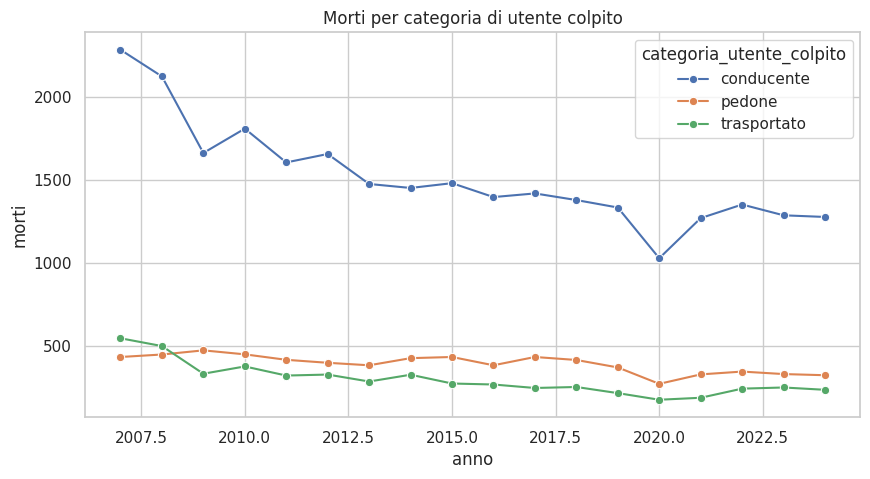

In [138]:
victim_cols = ['morti_conducenti','morti_trasportati','morti_pedoni']
victim_profile = (cause_core.groupby('causa')[victim_cols + ['morti_totale','incidenti']].sum()
                  .assign(quota_pedoni_pct=lambda x: x['morti_pedoni']/x['morti_totale'].replace(0,np.nan)*100,
                          quota_conducenti_pct=lambda x: x['morti_conducenti']/x['morti_totale'].replace(0,np.nan)*100,
                          quota_trasportati_pct=lambda x: x['morti_trasportati']/x['morti_totale'].replace(0,np.nan)*100)
                  .reset_index())
display(victim_profile.sort_values('morti_pedoni', ascending=False).head(15))

long_core = df_long[(df_long['tipo_riga'].eq('causa_specifica')) & (df_long['categoria_utente_colpito']!='totale')].copy()
long_core = long_core[~long_core['causa'].str.contains('Altre circostanze|imprecisate|concomitanti', case=False, na=False)]
cat_year = long_core.groupby(['anno','categoria_utente_colpito'], as_index=False)['morti'].sum()
if sns is not None:
    plt.figure(figsize=(10,5))
    sns.lineplot(data=cat_year, x='anno', y='morti', hue='categoria_utente_colpito', marker='o')
    plt.title('Morti per categoria di utente colpito')
    plt.show()
else:
    display(cat_year.head())

potrebbe essere indice di un'evoluzione della protezione interna delle vetture?

Nelle prossime scelte si analizzano feriti e morti assoluti, perdendo del dettaglio dei dati pool, ma focalizzandosi piu su quali cause danno piu feriti e morti in genreale piutttosto che quali sono le cause piu mortali o dannose per categoria, scelta operativa pratica

## 5.2 Cause di Morti

### 5.2.1 Top Cause di Morti, Conducenti/Trasportati/Pedoni

In [139]:
cause = df[df['tipo_riga'].eq('causa_specifica')].copy()
residuali = cause['causa'].str.contains('Altre circostanze|imprecisate|concomitanti', case=False, na=False)
cause_core = cause[~residuali].copy()

# Raggruppamento per l'analisi statica
ranking = (cause_core.groupby('causa', as_index=False)
           .agg(morti_conducenti=('morti_conducenti','sum'), 
                morti_trasportati=('morti_trasportati','sum'), 
                morti_pedoni=('morti_pedoni','sum'),
                anni_presenti=('anno','nunique')))

print("--- TOP 15 MORTI CONDUCENTI ---")
display(ranking.sort_values('morti_conducenti', ascending=False).head(15))
print("\n--- TOP 15 MORTI TRASPORTATI ---")
display(ranking.sort_values('morti_trasportati', ascending=False).head(15))
print("\n--- TOP 15 MORTI PEDONI ---")
display(ranking.sort_values('morti_pedoni', ascending=False).head(15))

--- TOP 15 MORTI CONDUCENTI ---


,causa,morti_conducenti,morti_trasportati,morti_pedoni,anni_presenti
9,[Conducente] Procedeva con guida distratta o andamento indeciso,"6,022.00","1,222.00",127.00,18
21,[Conducente] con eccesso di velocità,"5,661.00","1,471.00",988.00,18
23,[Conducente] contromano,"2,766.00",529.00,49.00,18
33,[Conducente] senza mantenere la distanza di sicurezza,"2,417.00",588.00,112.00,18
39,[Conducente] senza rispettare lo stop,"1,088.00",167.00,18.00,18
...,...,...,...,...,...
18,[Conducente] Svoltava a sinistra irregolarmente,524.00,48.00,6.00,18
10,[Conducente] Procedeva non in prossimità del margine destro della carreggiata,498.00,77.00,4.00,18
24,"[Conducente] in curva, su dosso o con insufficiente visibilità",361.00,56.00,5.00,18
35,[Conducente] senza rispettare i limiti di velocità,351.00,90.00,75.00,18



--- TOP 15 MORTI TRASPORTATI ---


,causa,morti_conducenti,morti_trasportati,morti_pedoni,anni_presenti
21,[Conducente] con eccesso di velocità,"5,661.00","1,471.00",988.00,18
9,[Conducente] Procedeva con guida distratta o andamento indeciso,"6,022.00","1,222.00",127.00,18
33,[Conducente] senza mantenere la distanza di sicurezza,"2,417.00",588.00,112.00,18
23,[Conducente] contromano,"2,766.00",529.00,49.00,18
39,[Conducente] senza rispettare lo stop,"1,088.00",167.00,18.00,18
...,...,...,...,...,...
56,[Ostacoli/Evitati] Ostacolo accidentale,225.00,78.00,0.00,18
10,[Conducente] Procedeva non in prossimità del margine destro della carreggiata,498.00,77.00,4.00,18
37,[Conducente] senza rispettare il segnale di dare precedenza,850.00,76.00,9.00,18
1,[Conducente] Anormale per ebbrezza da alcool,124.00,63.00,23.00,2



--- TOP 15 MORTI PEDONI ---


,causa,morti_conducenti,morti_trasportati,morti_pedoni,anni_presenti
7,[Conducente] Non dava la precedenza al pedone sugli appositi attraversamenti,19.00,0.00,"2,242.00",18
67,[Pedone] Attraversava la strada irregolarmente,14.00,1.00,"1,395.00",18
21,[Conducente] con eccesso di velocità,"5,661.00","1,471.00",988.00,18
69,[Pedone] Camminava in mezzo alla carreggiata,4.00,0.00,494.00,18
6,[Conducente] Manovrava in retrocessione o conversione,334.00,43.00,468.00,18
...,...,...,...,...,...
33,[Conducente] senza mantenere la distanza di sicurezza,"2,417.00",588.00,112.00,18
68,[Pedone] Camminava contromano,3.00,0.00,79.00,18
35,[Conducente] senza rispettare i limiti di velocità,351.00,90.00,75.00,18
70,[Pedone] Discendeva da veicolo con imprudenza,2.00,0.00,49.00,18


### 5.2.2 Top Cause di Morti, Conducenti/Trasportati/Pedoni-Trend Annuale

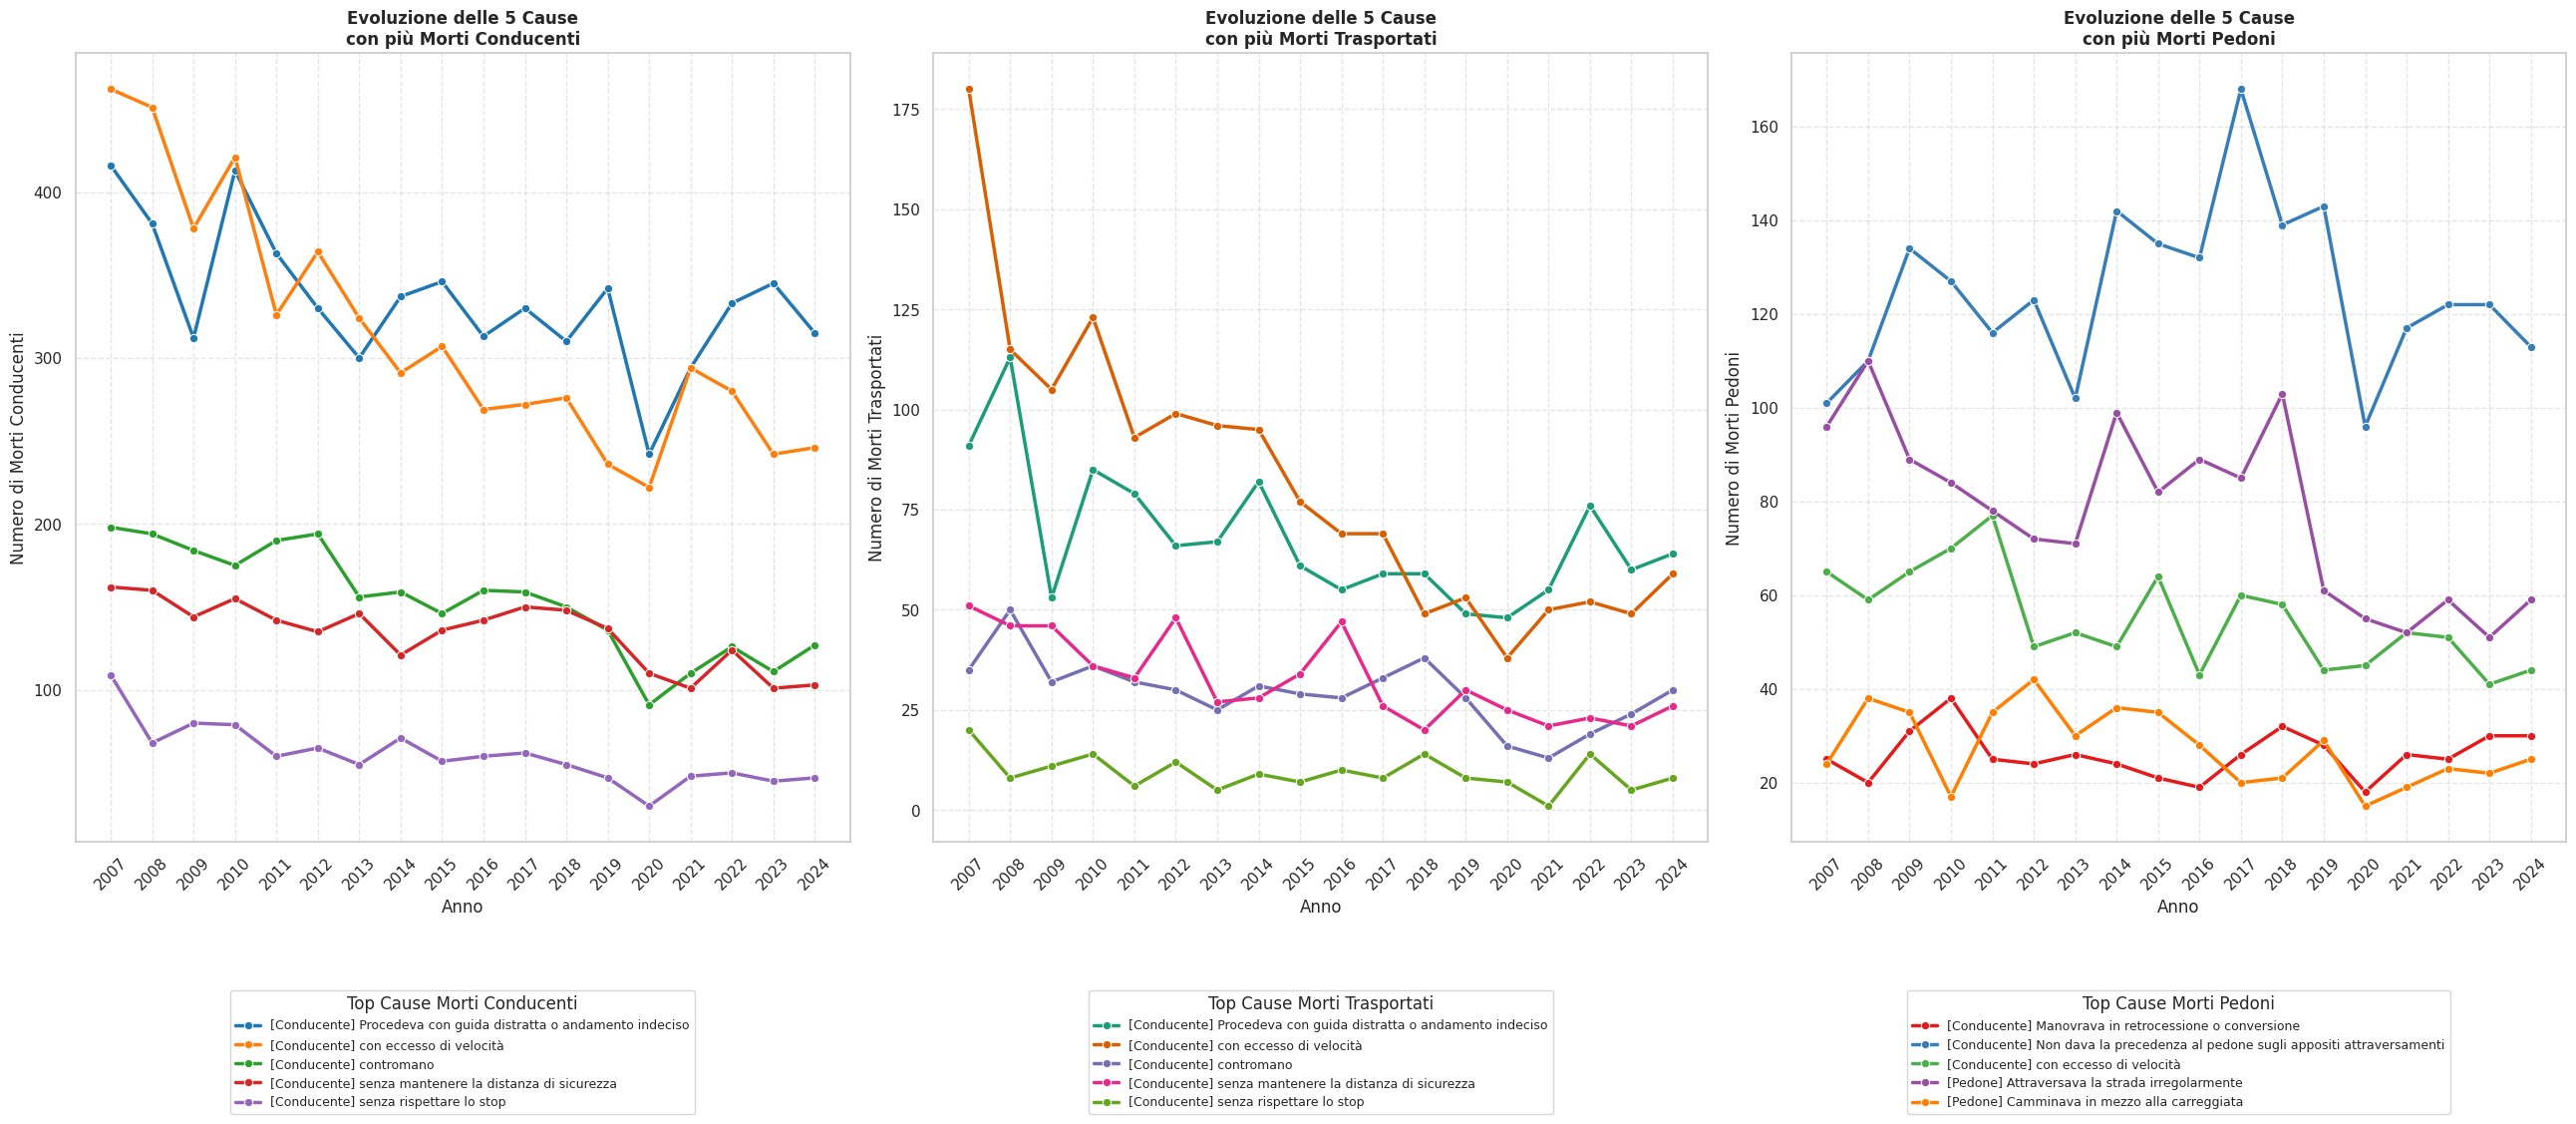

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. CALCOLO DEI TREND STORICI ANNALI
trend_annuale = (cause_core.groupby(['causa', 'anno'], as_index=False)
                 .agg(morti_conducenti=('morti_conducenti', 'sum'), 
                      morti_trasportati=('morti_trasportati', 'sum'),
                      morti_pedoni=('morti_pedoni', 'sum')))

anni_esatti = sorted(trend_annuale['anno'].unique())

# 2. SELEZIONE DELLE TOP 5 INDIPENDENTI CON FILTRO DI VOLUME E CONTINUITÀ
# --- Conducenti ---
soglia_25_c = ranking['morti_conducenti'].quantile(.25)
ranking_filtrato_c = ranking[ranking['morti_conducenti'] >= soglia_25_c]
ranking_continuita_c = ranking_filtrato_c[ranking_filtrato_c['anni_presenti'] >= 15]
top_5_morti_conducenti = ranking_continuita_c.sort_values('morti_conducenti', ascending=False).head(5)['causa'].tolist()

# --- Trasportati ---
soglia_25_t = ranking['morti_trasportati'].quantile(.25)
ranking_filtrato_t = ranking[ranking['morti_trasportati'] >= soglia_25_t]
ranking_continuita_t = ranking_filtrato_t[ranking_filtrato_t['anni_presenti'] >= 15]
top_5_morti_trasportati = ranking_continuita_t.sort_values('morti_trasportati', ascending=False).head(5)['causa'].tolist()

# --- Pedoni ---
soglia_25_p = ranking['morti_pedoni'].quantile(.25)
ranking_filtrato_p = ranking[ranking['morti_pedoni'] >= soglia_25_p]
ranking_continuita_p = ranking_filtrato_p[ranking_filtrato_p['anni_presenti'] >= 15]
top_5_morti_pedoni = ranking_continuita_p.sort_values('morti_pedoni', ascending=False).head(5)['causa'].tolist()


# 3. FILTRAGGIO DATASET PER IL PLOTTING
df_plot_morti_conducenti = trend_annuale[trend_annuale['causa'].isin(top_5_morti_conducenti)]
df_plot_morti_trasportati = trend_annuale[trend_annuale['causa'].isin(top_5_morti_trasportati)]
df_plot_morti_pedoni = trend_annuale[trend_annuale['causa'].isin(top_5_morti_pedoni)]


# 4. PLOTTING GENERALE AGGIORNATO (3 Grafici a Linee Affiancati)
fig, axes = plt.subplots(1, 3, figsize=(26, 11))

# --- GRAFICO 1: CONDUCENTI ---
sns.lineplot(data=df_plot_morti_conducenti, x='anno', y='morti_conducenti', hue='causa', marker='o', palette='tab10', ax=axes[0], linewidth=2.5)
axes[0].set_title('Evoluzione delle 5 Cause\ncon più Morti Conducenti', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Anno')
axes[0].set_ylabel('Numero di Morti Conducenti')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_xticks(anni_esatti)
axes[0].set_xticklabels(anni_esatti, rotation=45)
axes[0].legend(title='Top Cause Morti Conducenti', bbox_to_anchor=(0.5, -0.18), loc='upper center', fontsize=9)

# --- GRAFICO 2: TRASPORTATI ---
sns.lineplot(data=df_plot_morti_trasportati, x='anno', y='morti_trasportati', hue='causa', marker='o', palette='Dark2', ax=axes[1], linewidth=2.5)
axes[1].set_title('Evoluzione delle 5 Cause\ncon più Morti Trasportati', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Anno')
axes[1].set_ylabel('Numero di Morti Trasportati')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_xticks(anni_esatti)
axes[1].set_xticklabels(anni_esatti, rotation=45)
axes[1].legend(title='Top Cause Morti Trasportati', bbox_to_anchor=(0.5, -0.18), loc='upper center', fontsize=9)

# --- GRAFICO 3: PEDONI (Corretto df_plot_morti_pedoni) ---
sns.lineplot(data=df_plot_morti_pedoni, x='anno', y='morti_pedoni', hue='causa', marker='o', palette='Set1', ax=axes[2], linewidth=2.5)
axes[2].set_title('Evoluzione delle 5 Cause\ncon più Morti Pedoni', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Anno')
axes[2].set_ylabel('Numero di Morti Pedoni')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].set_xticks(anni_esatti)
axes[2].set_xticklabels(anni_esatti, rotation=45)
axes[2].legend(title='Top Cause Morti Pedoni', bbox_to_anchor=(0.5, -0.18), loc='upper center', fontsize=9)

plt.subplots_adjust(bottom=0.38)
plt.tight_layout()
plt.show()

## 5.3 Cause di Feriti

### 5.3.1 Top Cause per anno di Feriti, Conducenti/Trasportati/Pedoni

In [141]:
cause = df[df['tipo_riga'].eq('causa_specifica')].copy()
residuali = cause['causa'].str.contains('Altre circostanze|imprecisate|concomitanti', case=False, na=False)
cause_core = cause[~residuali].copy()

# Raggruppamento per l'analisi statica
ranking = (cause_core.groupby('causa', as_index=False)
           .agg(feriti_conducenti=('feriti_conducenti','sum'), 
                feriti_trasportati=('feriti_trasportati','sum'), 
                feriti_pedoni=('feriti_pedoni','sum'),
                anni_presenti=('anno','nunique')))

print("--- TOP 15 FERITI CONDUCENTI ---")
display(ranking.sort_values('feriti_conducenti', ascending=False).head(15))
print("\n--- TOP 15 FERITI TRASPORTATI ---")
display(ranking.sort_values('feriti_trasportati', ascending=False).head(15))
print("\n--- TOP 15 FERITI PEDONI ---")
display(ranking.sort_values('feriti_pedoni', ascending=False).head(15))

--- TOP 15 FERITI CONDUCENTI ---


,causa,feriti_conducenti,feriti_trasportati,feriti_pedoni,anni_presenti
9,[Conducente] Procedeva con guida distratta o andamento indeciso,"418,821.00","136,943.00","2,774.00",18
33,[Conducente] senza mantenere la distanza di sicurezza,"366,336.00","155,620.00","3,349.00",18
21,[Conducente] con eccesso di velocità,"265,729.00","109,575.00","21,038.00",18
39,[Conducente] senza rispettare lo stop,"205,016.00","71,321.00",673.00,18
37,[Conducente] senza rispettare il segnale di dare precedenza,"187,503.00","55,553.00",542.00,18
...,...,...,...,...,...
61,[Ostacoli/Urtati] Ostacolo accidentale,"37,657.00","10,702.00",0.00,18
6,[Conducente] Manovrava in retrocessione o conversione,"36,918.00","9,232.00","24,214.00",18
38,[Conducente] senza rispettare le segnalazioni semaforiche o dell'agente,"31,731.00","10,949.00","3,610.00",18
10,[Conducente] Procedeva non in prossimità del margine destro della carreggiata,"28,807.00","8,666.00",104.00,18



--- TOP 15 FERITI TRASPORTATI ---


,causa,feriti_conducenti,feriti_trasportati,feriti_pedoni,anni_presenti
33,[Conducente] senza mantenere la distanza di sicurezza,"366,336.00","155,620.00","3,349.00",18
9,[Conducente] Procedeva con guida distratta o andamento indeciso,"418,821.00","136,943.00","2,774.00",18
21,[Conducente] con eccesso di velocità,"265,729.00","109,575.00","21,038.00",18
39,[Conducente] senza rispettare lo stop,"205,016.00","71,321.00",673.00,18
37,[Conducente] senza rispettare il segnale di dare precedenza,"187,503.00","55,553.00",542.00,18
...,...,...,...,...,...
38,[Conducente] senza rispettare le segnalazioni semaforiche o dell'agente,"31,731.00","10,949.00","3,610.00",18
61,[Ostacoli/Urtati] Ostacolo accidentale,"37,657.00","10,702.00",0.00,18
6,[Conducente] Manovrava in retrocessione o conversione,"36,918.00","9,232.00","24,214.00",18
10,[Conducente] Procedeva non in prossimità del margine destro della carreggiata,"28,807.00","8,666.00",104.00,18



--- TOP 15 FERITI PEDONI ---


,causa,feriti_conducenti,feriti_trasportati,feriti_pedoni,anni_presenti
7,[Conducente] Non dava la precedenza al pedone sugli appositi attraversamenti,"5,849.00",597.00,"116,052.00",18
67,[Pedone] Attraversava la strada irregolarmente,"4,683.00",429.00,"46,672.00",18
6,[Conducente] Manovrava in retrocessione o conversione,"36,918.00","9,232.00","24,214.00",18
21,[Conducente] con eccesso di velocità,"265,729.00","109,575.00","21,038.00",18
69,[Pedone] Camminava in mezzo alla carreggiata,"1,072.00",97.00,"13,406.00",18
...,...,...,...,...,...
4,[Conducente] Fuoriusciva dalla carreggiata investendo il pedone,284.00,31.00,"2,947.00",18
9,[Conducente] Procedeva con guida distratta o andamento indeciso,"418,821.00","136,943.00","2,774.00",18
19,[Conducente] Urtava con il carico il pedone,95.00,11.00,"2,396.00",18
23,[Conducente] contromano,"78,718.00","27,580.00","2,150.00",18


### 5.3.2 Top Cause per anno di Feriti, Conducenti/Trasportati/Pedoni-Trend Annuale

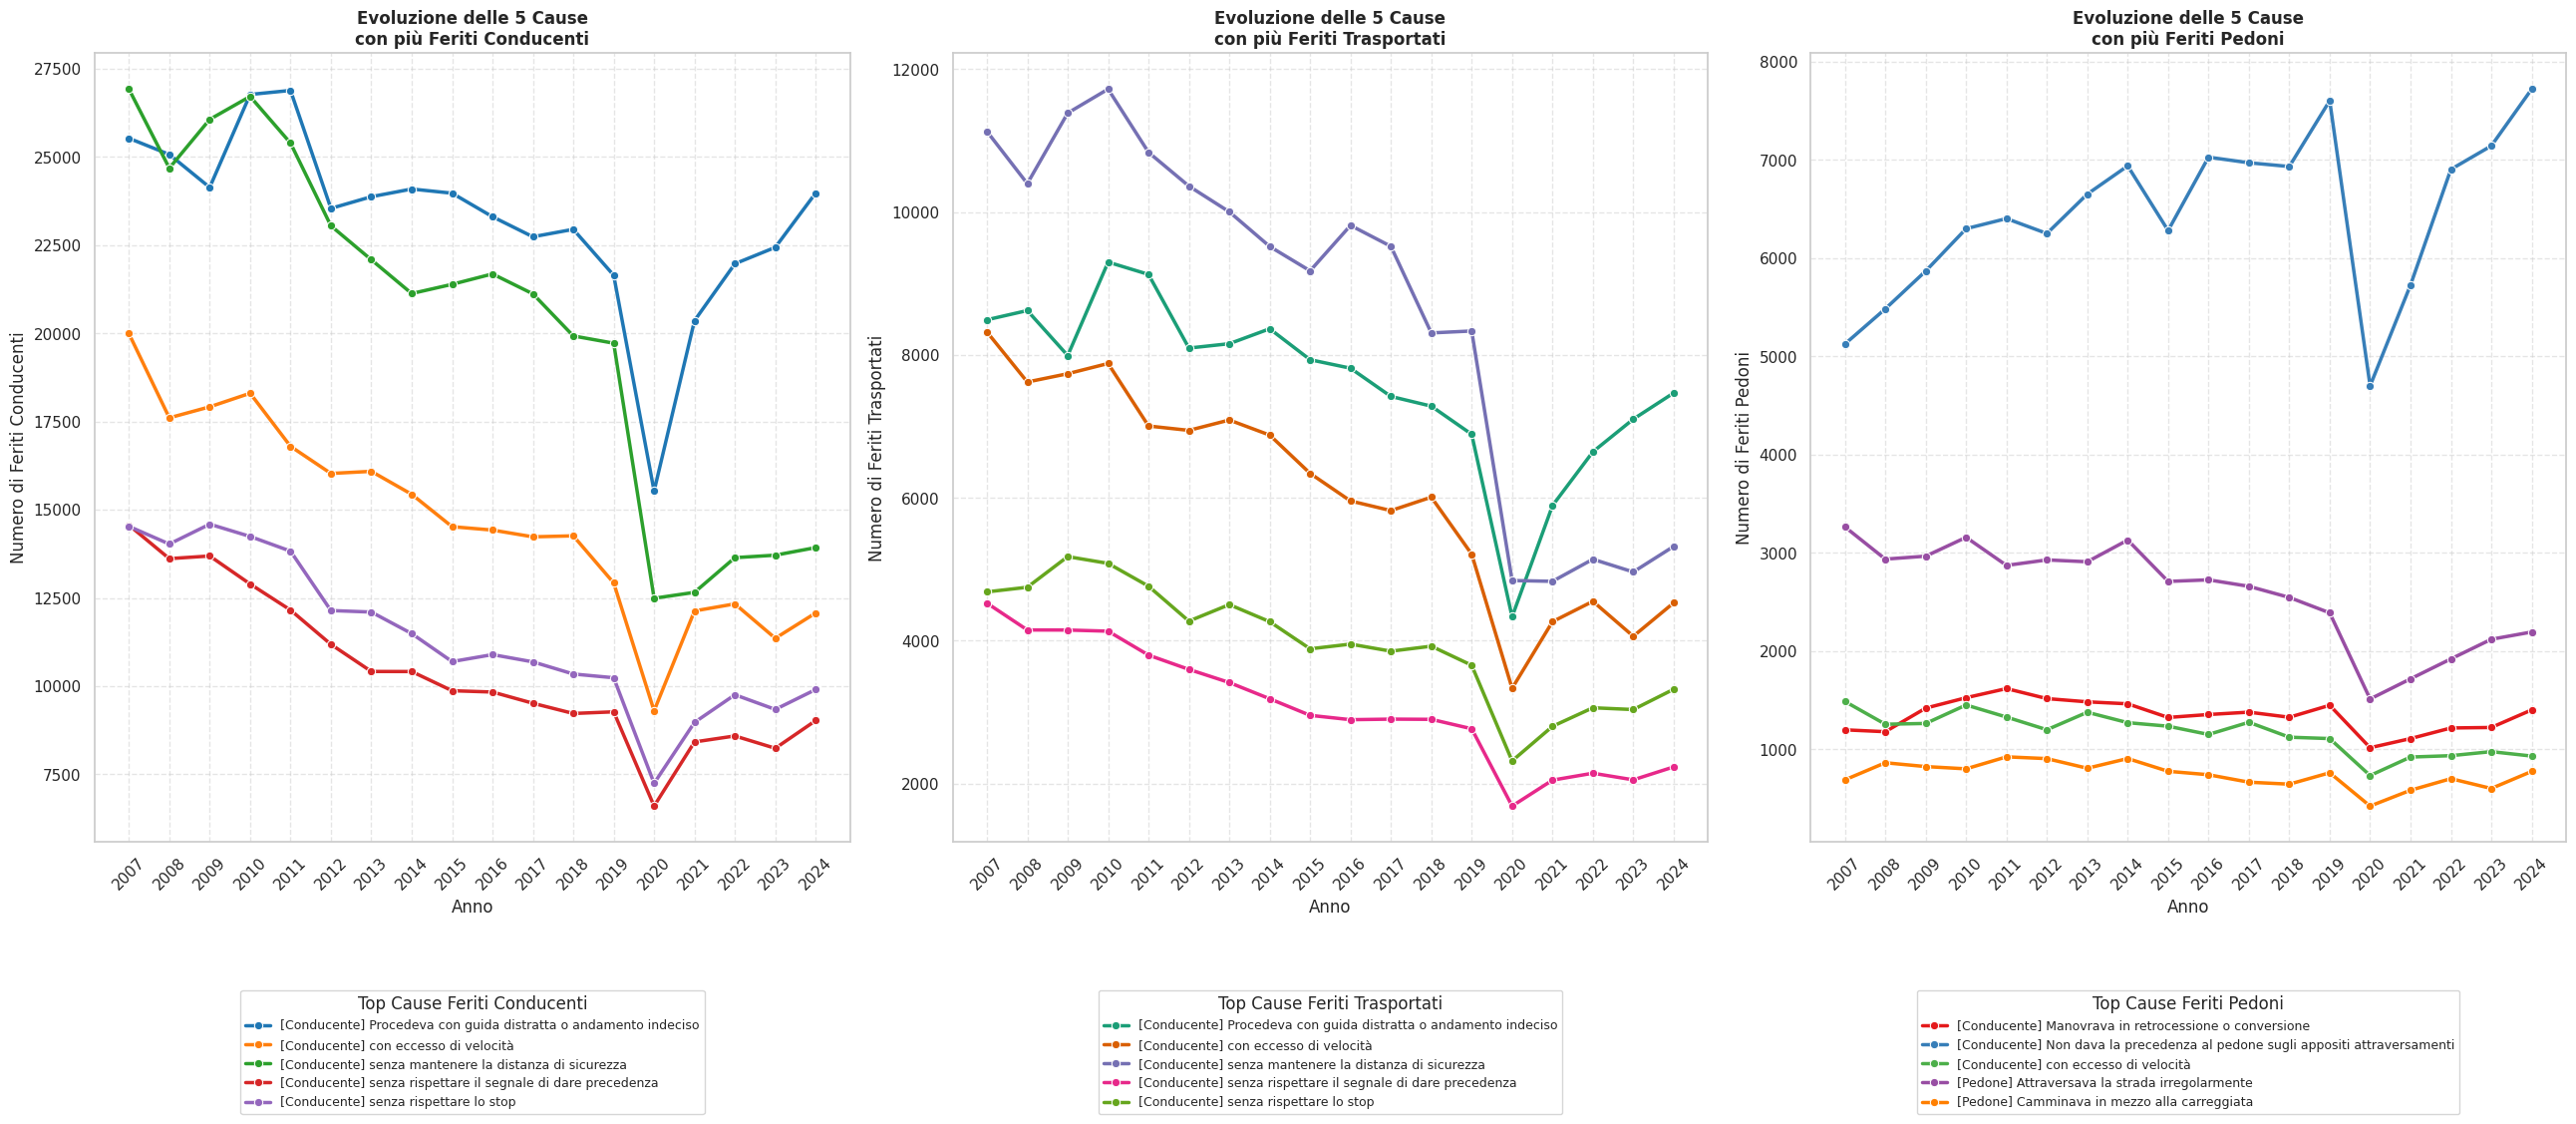

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. CALCOLO DEI TREND STORICI ANNALI
trend_annuale = (cause_core.groupby(['causa', 'anno'], as_index=False)
                 .agg(feriti_conducenti=('feriti_conducenti', 'sum'), 
                      feriti_trasportati=('feriti_trasportati', 'sum'),
                      feriti_pedoni=('feriti_pedoni', 'sum')))

anni_esatti = sorted(trend_annuale['anno'].unique())

# 2. SELEZIONE DELLE TOP 5 INDIPENDENTI CON FILTRO DI VOLUME E CONTINUITÀ
# --- Conducenti ---
soglia_25_c = ranking['feriti_conducenti'].quantile(.25)
ranking_filtrato_c = ranking[ranking['feriti_conducenti'] >= soglia_25_c]
ranking_continuita_c = ranking_filtrato_c[ranking_filtrato_c['anni_presenti'] >= 15]
top_5_feriti_conducenti = ranking_continuita_c.sort_values('feriti_conducenti', ascending=False).head(5)['causa'].tolist()

# --- Trasportati ---
soglia_25_t = ranking['feriti_trasportati'].quantile(.25)
ranking_filtrato_t = ranking[ranking['feriti_trasportati'] >= soglia_25_t]
ranking_continuita_t = ranking_filtrato_t[ranking_filtrato_t['anni_presenti'] >= 15]
top_5_feriti_trasportati = ranking_continuita_t.sort_values('feriti_trasportati', ascending=False).head(5)['causa'].tolist()

# --- Pedoni ---
soglia_25_p = ranking['feriti_pedoni'].quantile(.25)
ranking_filtrato_p = ranking[ranking['feriti_pedoni'] >= soglia_25_p]
ranking_continuita_p = ranking_filtrato_p[ranking_filtrato_p['anni_presenti'] >= 15]
top_5_feriti_pedoni = ranking_continuita_p.sort_values('feriti_pedoni', ascending=False).head(5)['causa'].tolist()

# 3. FILTRAGGIO DATASET PER IL PLOTTING
df_plot_feriti_conducenti = trend_annuale[trend_annuale['causa'].isin(top_5_feriti_conducenti)]
df_plot_feriti_trasportati = trend_annuale[trend_annuale['causa'].isin(top_5_feriti_trasportati)]
df_plot_feriti_pedoni = trend_annuale[trend_annuale['causa'].isin(top_5_feriti_pedoni)]


# 4. PLOTTING GENERALE AGGIORNATO (3 Grafici a Linee Affiancati)
fig, axes = plt.subplots(1, 3, figsize=(26, 11))

# --- GRAFICO 1: CONDUCENTI ---
sns.lineplot(data=df_plot_feriti_conducenti, x='anno', y='feriti_conducenti', hue='causa', marker='o', palette='tab10', ax=axes[0], linewidth=2.5)
axes[0].set_title('Evoluzione delle 5 Cause\ncon più Feriti Conducenti', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Anno')
axes[0].set_ylabel('Numero di Feriti Conducenti')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_xticks(anni_esatti)
axes[0].set_xticklabels(anni_esatti, rotation=45)
axes[0].legend(title='Top Cause Feriti Conducenti', bbox_to_anchor=(0.5, -0.18), loc='upper center', fontsize=9)
# --- GRAFICO 2: TRASPORTATI ---
sns.lineplot(data=df_plot_feriti_trasportati, x='anno', y='feriti_trasportati', hue='causa', marker='o', palette='Dark2', ax=axes[1], linewidth=2.5)
axes[1].set_title('Evoluzione delle 5 Cause\ncon più Feriti Trasportati', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Anno')
axes[1].set_ylabel('Numero di Feriti Trasportati')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_xticks(anni_esatti)
axes[1].set_xticklabels(anni_esatti, rotation=45)
axes[1].legend(title='Top Cause Feriti Trasportati', bbox_to_anchor=(0.5, -0.18), loc='upper center', fontsize=9)

# --- GRAFICO 3: PEDONI (Corretto df_plot_feriti_pedoni) ---
sns.lineplot(data=df_plot_feriti_pedoni, x='anno', y='feriti_pedoni', hue='causa', marker='o', palette='Set1', ax=axes[2], linewidth=2.5)
axes[2].set_title('Evoluzione delle 5 Cause\ncon più Feriti Pedoni', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Anno')
axes[2].set_ylabel('Numero di Feriti Pedoni')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].set_xticks(anni_esatti)
axes[2].set_xticklabels(anni_esatti, rotation=45)
axes[2].legend(title='Top Cause Feriti Pedoni', bbox_to_anchor=(0.5, -0.18), loc='upper center', fontsize=9)
plt.subplots_adjust(bottom=0.38)
plt.tight_layout()
plt.show()

### 5.4 Approfondimento, Mortalità delle Cause

Una causa con un alto numero di morti per una categoria rappresenta sicuramente un punto di interesse politico, tuttavia, dal momento in cui l'aumento o la diminuzione del numero di morti per categoria attribuibile ad una causa, non comporta un'aumento o diminuzione della Mortalità della causa, ma potrebbe essere dovuto ad un aumento o diminuzione del numero di incidenti per quella causa in generale, sono stati calcolati i tassi di mortalità di ogni causa divisi per categoria.


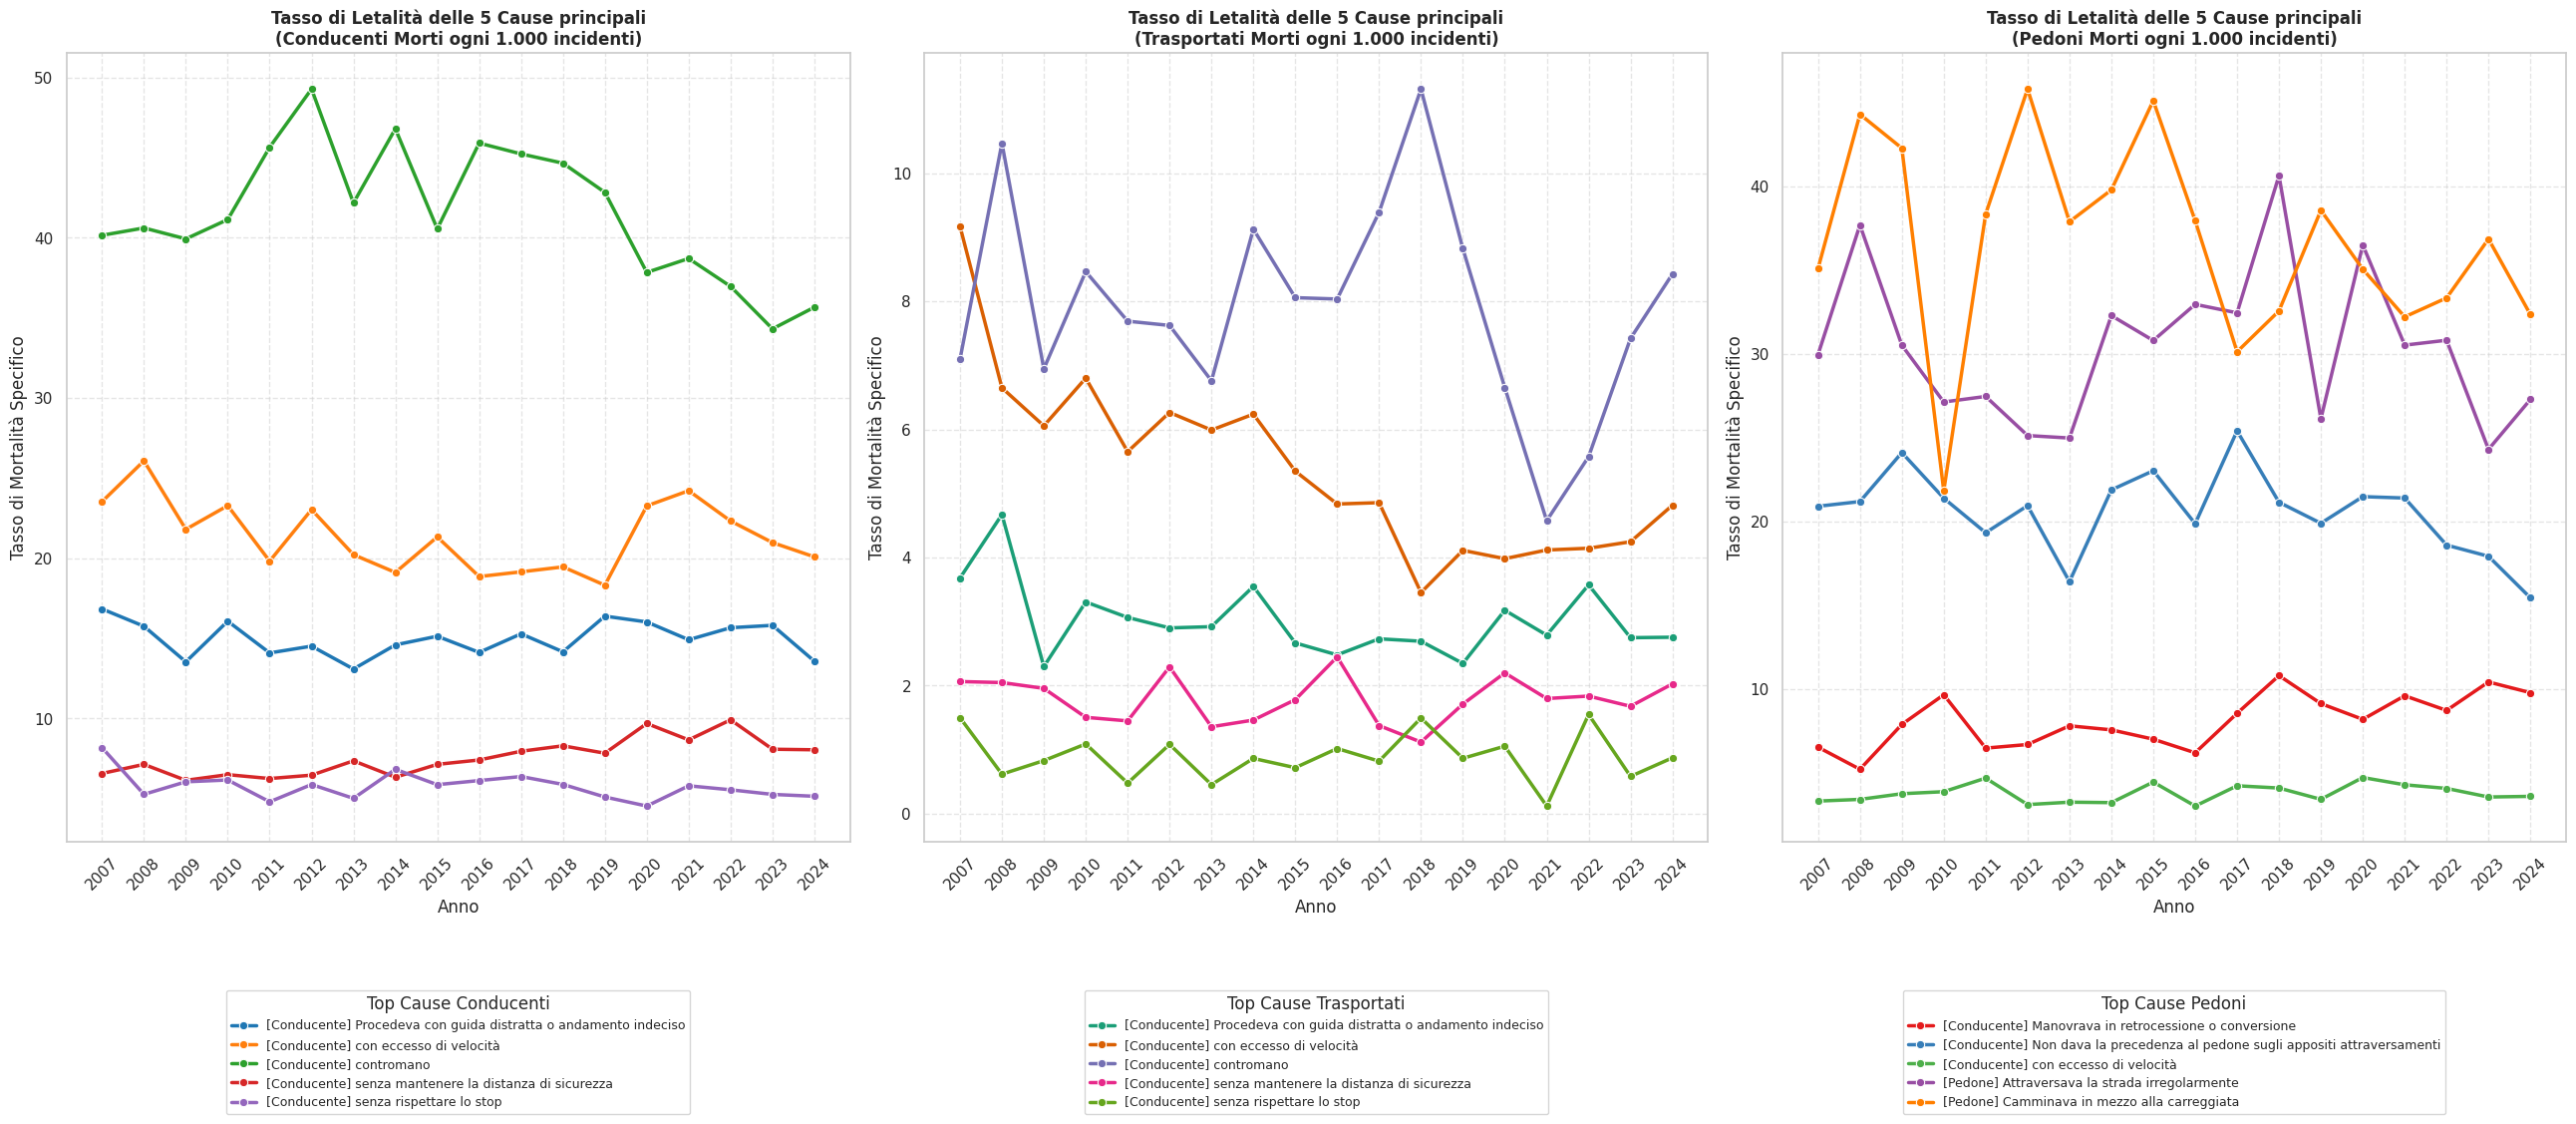

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =====================================================================
# BLOCCO 1: RANKING STATICO GLOBALE CON AGGREGAZIONE INCIDENTI (CORRETTO)
# =====================================================================
cause = df[df['tipo_riga'].eq('causa_specifica')].copy()
residuali = cause['causa'].str.contains('Altre circostanze|imprecisate|concomitanti', case=False, na=False)
cause_core = cause[~residuali].copy()

ranking = (cause_core.groupby('causa', as_index=False)
           .agg(incidenti=('incidenti', 'sum'), # <--- AGGIUNTO QUI: serve come base stabile per i filtri
                morti_conducenti=('morti_conducenti','sum'), 
                morti_trasportati=('morti_trasportati','sum'), 
                morti_pedoni=('morti_pedoni','sum'),
                anni_presenti=('anno','nunique')))


# =====================================================================
# 1. CALCOLO DEI TREND STORICI ANNALI
# =====================================================================
trend_annuale = (cause_core.groupby(['causa', 'anno'], as_index=False)
                 .agg(incidenti=('incidenti', 'sum'), 
                      morti_conducenti=('morti_conducenti', 'sum'), 
                      morti_trasportati=('morti_trasportati', 'sum'),
                      morti_pedoni=('morti_pedoni', 'sum')))

# Calcolo dei tassi specifici purificati
trend_annuale['tasso_conducenti'] = (trend_annuale['morti_conducenti'] / trend_annuale['incidenti'].replace(0, np.nan) * 1000)
trend_annuale['tasso_trasportati'] = (trend_annuale['morti_trasportati'] / trend_annuale['incidenti'].replace(0, np.nan) * 1000)
trend_annuale['tasso_pedoni'] = (trend_annuale['morti_pedoni'] / trend_annuale['incidenti'].replace(0, np.nan) * 1000)

anni_esatti = sorted(trend_annuale['anno'].unique())


# =====================================================================
# 2. SELEZIONE DELLE TOP 5 CON SOGLIA UNIFICATA SUL VOLUME DI INCIDENTI
# =====================================================================
# Usiamo il 25° percentile degli INCIDENTI TOTALI come filtro di stabilità statistica universale
soglia_volume = ranking['incidenti'].quantile(.25)
ranking_stabilizzato = ranking[ranking['incidenti'] >= soglia_volume]

# Applichiamo la continuità storica (almeno 15 anni su 18)
ranking_continuita = ranking_stabilizzato[ranking_stabilizzato['anni_presenti'] >= 15]

# Ora estraiamo le top 5 specifiche per ogni categoria di utente
top_5_morti_conducenti = ranking_continuita.sort_values('morti_conducenti', ascending=False).head(5)['causa'].tolist()
top_5_morti_trasportati = ranking_continuita.sort_values('morti_trasportati', ascending=False).head(5)['causa'].tolist()
top_5_morti_pedoni = ranking_continuita.sort_values('morti_pedoni', ascending=False).head(5)['causa'].tolist()


# =====================================================================
# 3. FILTRAGGIO DATASET PER IL PLOTTING
# =====================================================================
df_plot_morti_conducenti = trend_annuale[trend_annuale['causa'].isin(top_5_morti_conducenti)]
df_plot_morti_trasportati = trend_annuale[trend_annuale['causa'].isin(top_5_morti_trasportati)]
df_plot_morti_pedoni = trend_annuale[trend_annuale['causa'].isin(top_5_morti_pedoni)]


# =====================================================================
# 4. PLOTTING GENERALE DEI TASSI (3 Grafici a Linee Affiancati)
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(26, 11))

# --- GRAFICO 1: CONDUCENTI ---
sns.lineplot(data=df_plot_morti_conducenti, x='anno', y='tasso_conducenti', hue='causa', marker='o', palette='tab10', ax=axes[0], linewidth=2.5)
axes[0].set_title('Tasso di Letalità delle 5 Cause principali\n(Conducenti Morti ogni 1.000 incidenti)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Anno')
axes[0].set_ylabel('Tasso di Mortalità Specifico')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_xticks(anni_esatti)
axes[0].set_xticklabels(anni_esatti, rotation=45)
axes[0].legend(title='Top Cause Conducenti', bbox_to_anchor=(0.5, -0.18), loc='upper center', fontsize=9)

# --- GRAFICO 2: TRASPORTATI ---
sns.lineplot(data=df_plot_morti_trasportati, x='anno', y='tasso_trasportati', hue='causa', marker='o', palette='Dark2', ax=axes[1], linewidth=2.5)
axes[1].set_title('Tasso di Letalità delle 5 Cause principali\n(Trasportati Morti ogni 1.000 incidenti)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Anno')
axes[1].set_ylabel('Tasso di Mortalità Specifico')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_xticks(anni_esatti)
axes[1].set_xticklabels(anni_esatti, rotation=45)
axes[1].legend(title='Top Cause Trasportati', bbox_to_anchor=(0.5, -0.18), loc='upper center', fontsize=9)

# --- GRAFICO 3: PEDONI ---
sns.lineplot(data=df_plot_morti_pedoni, x='anno', y='tasso_pedoni', hue='causa', marker='o', palette='Set1', ax=axes[2], linewidth=2.5)
axes[2].set_title('Tasso di Letalità delle 5 Cause principali\n(Pedoni Morti ogni 1.000 incidenti)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Anno')
axes[2].set_ylabel('Tasso di Mortalità Specifico')
axes[2].grid(True, linestyle='--', alpha=0.5)
axes[2].set_xticks(anni_esatti)
axes[2].set_xticklabels(anni_esatti, rotation=45)
axes[2].legend(title='Top Cause Pedoni', bbox_to_anchor=(0.5, -0.18), loc='upper center', fontsize=9)

plt.subplots_adjust(bottom=0.38)
plt.tight_layout()
plt.show()

# 6. Correlazioni e variabili derivate

In questa sezione le correlazioni non vengono lette come relazioni causali, ma come segnali diagnostici. L'obiettivo e capire quali variabili si muovono insieme, quanto le relazioni siano approssimativamente lineari e se outlier o asimmetrie rendano fragile una regressione lineare sui conteggi.


In [ ]:
features_base = [
    'incidenti', 'morti_totale', 'feriti_totale',
    'mortalita_per_1000_incidenti', 'feriti_per_1000_incidenti',
    'letalita_su_vittime_pct', 'quota_morti_pedoni_pct',
    'quota_morti_conducenti_pct', 'quota_morti_trasportati_pct',
    'quota_incidenti_anno_pct', 'quota_morti_anno_pct'
]
features_base = [c for c in features_base if c in cause_core.columns]

corr_df = cause_core[features_base].replace([np.inf, -np.inf], np.nan).dropna()
pearson_corr = corr_df.corr(method='pearson')
spearman_corr = corr_df.corr(method='spearman')

if sns is not None:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='vlag', center=0, ax=axes[0])
    axes[0].set_title('Pearson: relazione lineare')
    sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='vlag', center=0, ax=axes[1])
    axes[1].set_title('Spearman: relazione monotona robusta ai ranghi')
    plt.tight_layout()
    plt.show()
else:
    display(pearson_corr)
    display(spearman_corr)

pairs = []
for i, left in enumerate(features_base):
    for right in features_base[i+1:]:
        pairs.append({
            'variabile_1': left,
            'variabile_2': right,
            'pearson': pearson_corr.loc[left, right],
            'spearman': spearman_corr.loc[left, right],
            'delta_abs': abs(spearman_corr.loc[left, right] - pearson_corr.loc[left, right])
        })

corr_pairs = pd.DataFrame(pairs)
print('Relazioni lineari piu forti (Pearson):')
display(corr_pairs.assign(abs_pearson=lambda d: d['pearson'].abs())
        .sort_values('abs_pearson', ascending=False)
        .drop(columns='abs_pearson')
        .head(10))

print('Casi in cui Spearman e Pearson divergono di piu:')
display(corr_pairs.sort_values('delta_abs', ascending=False).head(10))


**Lettura interpretativa.**

Le correlazioni piu alte tra `incidenti`, `feriti_totale` e `morti_totale` misurano soprattutto un effetto volume: le cause piu frequenti generano piu eventi e quindi, meccanicamente, piu feriti e piu morti. Questo non significa che siano necessariamente le cause piu letali.

Per questo vanno separati i conteggi assoluti dagli indicatori di severita (`mortalita_per_1000_incidenti`, `letalita_su_vittime_pct`) e dagli indicatori di composizione (`quota_morti_pedoni_pct`, `quota_morti_conducenti_pct`, `quota_morti_trasportati_pct`). Se Pearson e Spearman sono simili, la relazione e abbastanza coerente anche in senso lineare. Se invece Spearman e molto piu alto o piu basso di Pearson, la relazione e probabilmente monotona ma non lineare, oppure guidata da pochi valori estremi.


## 6.1 Outlier e asimmetria delle distribuzioni

I dati sono conteggi aggregati per anno e causa. E normale osservare molte cause rare e poche cause molto frequenti: questa struttura produce code lunghe e outlier ad alto volume. In una regressione lineare questi punti possono avere leva elevata e influenzare molto la retta stimata.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_analisi = cause_core.copy()
features_outlier = [
    'incidenti', 'morti_totale', 'feriti_totale',
    'mortalita_per_1000_incidenti', 'letalita_su_vittime_pct',
    'quota_morti_pedoni_pct'
]
features_outlier = [c for c in features_outlier if c in df_analisi.columns]

outlier_rows = []
for col in features_outlier:
    q1 = df_analisi[col].quantile(0.25)
    q3 = df_analisi[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr
    mask = (df_analisi[col] < lower) | (df_analisi[col] > upper)
    outlier_rows.append({
        'variabile': col,
        'min': df_analisi[col].min(),
        'mediana': df_analisi[col].median(),
        'max': df_analisi[col].max(),
        'asimmetria_skew': df_analisi[col].skew(),
        'outlier_iqr_n': mask.sum(),
        'outlier_iqr_pct': mask.mean() * 100
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values('outlier_iqr_pct', ascending=False)
display(outlier_summary)

fig, axes = plt.subplots(len(features_outlier), 2, figsize=(16, 4 * len(features_outlier)))
if len(features_outlier) == 1:
    axes = np.array([axes])

for i, col in enumerate(features_outlier):
    sns.boxplot(data=df_analisi, x=col, y='macro_categoria', ax=axes[i, 0], color='#8ecae6')
    axes[i, 0].set_title(f'{col}: scala originale')
    axes[i, 0].set_xlabel('')
    axes[i, 0].set_ylabel('')

    sns.boxplot(data=df_analisi, x=col, y='macro_categoria', ax=axes[i, 1], color='#ffb703')
    if df_analisi[col].min() <= 0:
        axes[i, 1].set_xscale('symlog', linthresh=1.0)
    else:
        axes[i, 1].set_xscale('log')
    axes[i, 1].set_title(f'{col}: scala log/symlog')
    axes[i, 1].set_xlabel('')
    axes[i, 1].set_ylabel('')

plt.tight_layout()
plt.show()


**Perche questo conta per la regressione lineare.**

Una regressione lineare classica assume una relazione additiva e approssimativamente lineare, con errori non dominati da pochi punti estremi. Qui invece i conteggi hanno distribuzioni molto asimmetriche: poche cause concentrano gran parte degli incidenti e molte cause stanno su livelli bassi. La scala logaritmica non cambia i dati, ma rende leggibile questa differenza di ordini di grandezza e mostra quando la relazione e piu moltiplicativa che additiva.


## 6.2 Verifica preliminare di linearita

Prima di usare modelli lineari, conviene controllare se le relazioni principali sono rette plausibili oppure forme curve, a ventaglio o separate per macro-categoria. Queste forme segnalano non linearita, eteroschedasticita o interazioni tra categorie.


In [ ]:
features_scatter = [
    'incidenti', 'feriti_totale', 'mortalita_per_1000_incidenti',
    'letalita_su_vittime_pct', 'quota_morti_pedoni_pct', 'morti_totale'
]
features_scatter = [c for c in features_scatter if c in df_analisi.columns]
plot_df = df_analisi[features_scatter + ['macro_categoria']].replace([np.inf, -np.inf], np.nan).dropna()

if sns is not None and len(plot_df) > 0:
    grid = sns.pairplot(
        data=plot_df,
        hue='macro_categoria',
        diag_kind='hist',
        corner=True,
        plot_kws={'alpha': 0.55, 's': 28}
    )
    grid.fig.suptitle('Verifica preliminare di linearita per macro-categoria', y=1.02, fontsize=14, fontweight='bold')
    plt.show()

    grid = sns.pairplot(
        data=plot_df,
        hue='macro_categoria',
        diag_kind='hist',
        corner=True,
        plot_kws={'alpha': 0.55, 's': 28}
    )
    for ax in grid.axes.flat:
        if ax is not None:
            if ax.get_xlabel() in ['incidenti', 'feriti_totale', 'morti_totale']:
                ax.set_xscale('symlog', linthresh=1.0)
            if ax.get_ylabel() in ['incidenti', 'feriti_totale', 'morti_totale']:
                ax.set_yscale('symlog', linthresh=1.0)
    grid.fig.suptitle('Stessa verifica con assi log/symlog sui conteggi', y=1.02, fontsize=14, fontweight='bold')
    plt.show()


**Sintesi diagnostica del punto 6.**

Dalla struttura dei dati emergono tre motivi per cui una regressione lineare semplice sui conteggi puo fallire o risultare poco interpretabile: forte effetto volume, outlier ad alta leva e relazioni non necessariamente lineari. Le correlazioni sono quindi utili per descrivere associazioni e ridondanze tra variabili, ma non bastano per prevedere bene i morti totali. Per questo, nella parte predittiva, il modello lineare viene usato come baseline e confrontato con Lasso e Random Forest.


# 7. Dimensionality reduction: PCA

La PCA non viene mantenuta come analisi principale. In questo dataset le prime componenti tendono soprattutto a riassumere il contrasto tra volume degli eventi e indicatori di severita/composizione, informazione gia leggibile dalle correlazioni e poi usata in modo piu interpretabile nel clustering. Poiche non aggiunge una segmentazione piu chiara delle cause, e piu utile conservare il clustering gerarchico del punto 8 e dedicare la parte predittiva al confronto tra modelli.


# 8. Clustering delle cause

Il clustering raggruppa cause simili per frequenza, severita e profilo delle vittime. Questo aiuta a proporre interventi: alcune cause sono di massa, altre sono piu rare ma molto letali.

## 8.1. Flip del Dataset per Clustering

In [150]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Filtriamo solo le cause specifiche (escludiamo le righe macro_categoria e i totali)
df_micro = df[df['tipo_riga'] == 'causa_specifica'].copy()

# 3. Aggreghiamo facendo la SOMMA di tutti i 18 anni per ogni singola causa
# Questo ci serve per calcolare i tassi globali senza risentire di un singolo anno anomalo
df_sum = df_micro.groupby('causa').sum(numeric_only=True).reset_index()

# 4. Creiamo la matrice per il Clustering calcolando le 5 FEATURE RICHIESTE
df_cluster = pd.DataFrame()
df_cluster['causa'] = df_sum['causa']

#Feature 0, Macro di appartenenza
df_cluster['macro'] = (df['macro_categoria']) 

# Feature 1: Tasso di Mortalità Generale (per 1000 incidenti)
df_cluster['mortalita_rate'] = (df_sum['morti_totale'] / df_sum['incidenti']) * 1000

# Feature 2: Tasso di Ferimento Generale (per 1000 incidenti)
df_cluster['feriti_rate'] = (df_sum['feriti_totale'] / df_sum['incidenti']) * 1000

# Feature 3: Quota Morti Conducenti (sul totale dei morti di quella causa)
# Usiamo .fillna(0) nel caso una causa abbia fatto 0 morti totali in 18 anni
df_cluster['quota_morti_conducenti'] = (df_sum['morti_conducenti'] / df_sum['morti_totale']).fillna(0)

# Feature 4: Quota Morti Vulnerabili (Pedoni + Trasportati) sul totale dei morti della causa
df_cluster['quota_morti_vulnerabili'] = ((df_sum['morti_pedoni'] + df_sum['morti_trasportati']) / df_sum['morti_totale']).fillna(0)

# Feature 5 (La tua intuizione!): Volume Assoluto di Morti Generati (Media annuale nei 18 anni)
df_cluster['morti_medi_annui'] = df_sum['morti_totale'] / 18

# Impostiamo la causa come indice della tabella
df_cluster.set_index('causa', inplace=True)

In [151]:
display(df_cluster.head(100))
df_cluster.describe

,macro,mortalita_rate,feriti_rate,quota_morti_conducenti,quota_morti_vulnerabili,morti_medi_annui
causa,,,,,,
[Conducente] Abbagliato,Circostanze riferibili al conducente per comportamento nella circolazione,39.22,"1,339.87",0.83,0.17,0.33
[Conducente] Anormale per ebbrezza da alcool,Circostanze riferibili al conducente per comportamento nella circolazione,29.34,"1,589.27",0.59,0.41,11.67
[Conducente] Attraversava imprudentemente il passaggio a livello,Circostanze riferibili al conducente per comportamento nella circolazione,66.67,"1,093.33",1.00,0.00,0.28
[Conducente] Frenava improvvisamente con conseguenza ai trasportati,Circostanze riferibili al conducente per comportamento nella circolazione,3.02,"1,109.50",0.53,0.47,0.83
[Conducente] Fuoriusciva dalla carreggiata investendo il pedone,Circostanze riferibili al conducente per comportamento nella circolazione,42.06,"1,193.12",0.02,0.98,6.39
...,...,...,...,...,...,...
[Pedone] Veniva fuori improvvisamente da dietro veicolo in sosta o fermata,Circostanze riferibili ad ostacoli evitati,23.91,"1,101.60",0.02,0.98,13.11
[Pedone] per condizioni morbose in atto,Circostanze riferibili ad ostacoli evitati,0.00,"1,000.00",0.00,0.00,0.00
[Pedone] per improvviso malore,Circostanze riferibili ad ostacoli evitati,333.33,"1,000.00",0.00,1.00,0.06


<bound method NDFrame.describe of                                                                                                                                                 macro  \
causa                                                                                                                                                   
[Conducente] Abbagliato                                                     Circostanze riferibili al conducente per comportamento nella circolazione   
[Conducente] Anormale per ebbrezza da alcool                                Circostanze riferibili al conducente per comportamento nella circolazione   
[Conducente] Attraversava imprudentemente il passaggio a livello            Circostanze riferibili al conducente per comportamento nella circolazione   
[Conducente] Frenava improvvisamente con conseguenza ai trasportati         Circostanze riferibili al conducente per comportamento nella circolazione   
[Conducente] Fuoriusciva dalla carreggiata inves

## 8.1. Pairplot filtrato per Macro Pre-Clustering

In [152]:
# Filtriamo le macro-categorie per un singolo anno (usando l'intero 2007, senza virgolette)
df_macro_2007 = df[(df['anno'] == 2007) & (df['tipo_riga'] == 'macro_categoria')]

# Estraiamo l'elenco delle macro-categorie uniche presenti nel dataset
macro_uniche = df_macro_2007['macro_categoria'].unique()
num_macro = len(macro_uniche)

print(f"Numero esatto di Macro-categorie: {num_macro}")
print("Elenco delle macro-categorie che verranno colorate:")
for i, macro in enumerate(macro_uniche, 1):
    print(f"{i}. {macro}")

Numero esatto di Macro-categorie: 8
Elenco delle macro-categorie che verranno colorate:
1. Circostanze riferibili al conducente per comportamento nella circolazione
2. Circostanze riferibili allo stato psico-fisico del conducente
3. Circostanze riferibili ai pedoni
4. Circostanze riferibili allo stato psico-fisico dei pedoni
5. Circostanze riferibili alle persone trasportate
6. Circostanze riferibili a difetti o avarie del veicolo
7. Circostanze riferibili ad ostacoli urtati
8. Circostanze riferibili ad ostacoli evitati


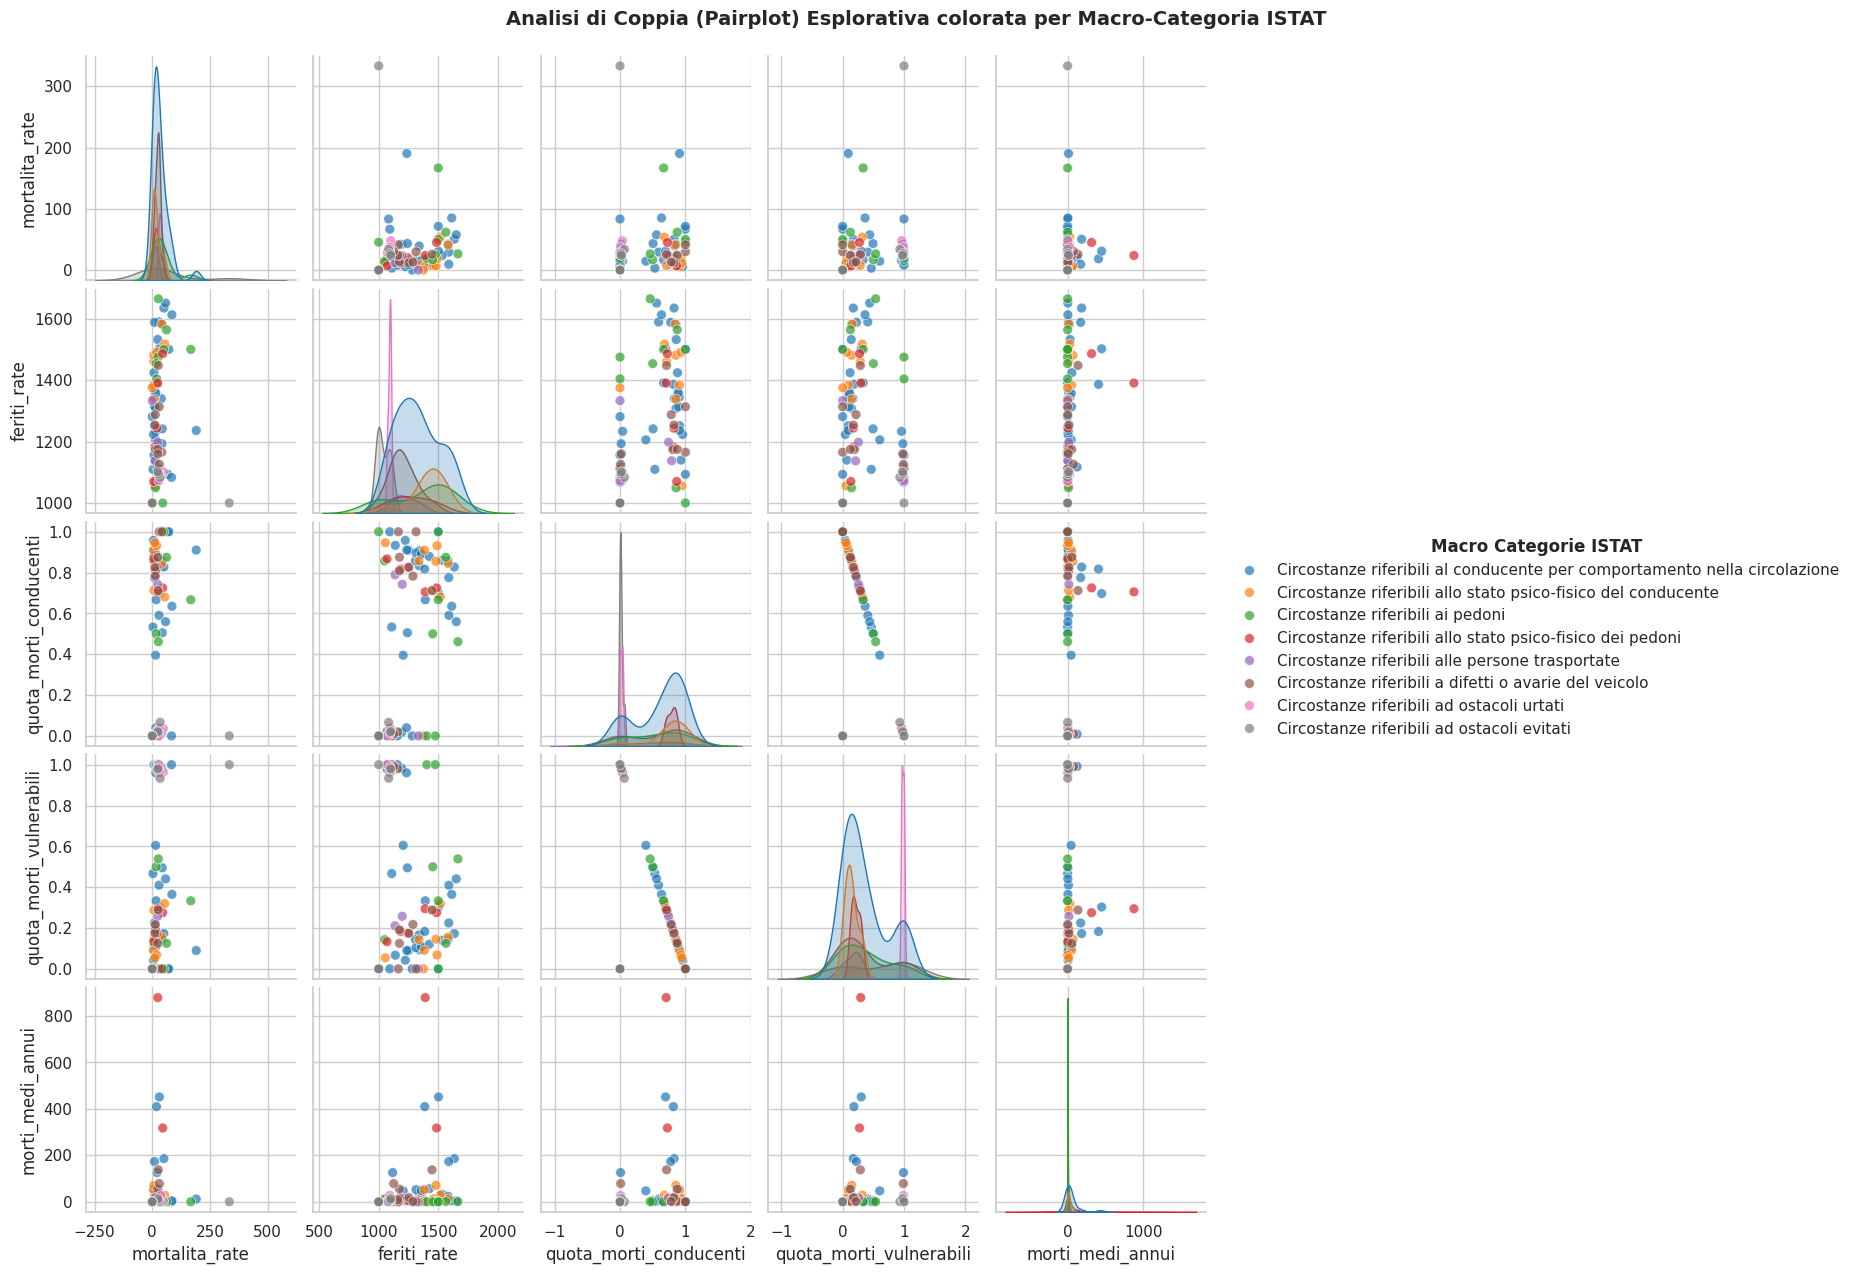

In [153]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scegliamo una palette robusta per 8 categorie (es. 'tab10')
palette_colori = "tab10"

# Creiamo il Pairplot delle 5 feature numeriche, colorando i punti in base alla macro_categoria
# Impostiamo diag_kind="kde" per vedere le curve di densità sui grafici diagonali
g = sns.pairplot(
    df_cluster, 
    hue="macro", 
    diag_kind="kde", 
    palette=palette_colori,
    plot_kws={'alpha': 0.7, 's': 50} # alpha rende i punti leggermente trasparenti per vedere le sovrapposizioni
)

# Regoliamo la legenda per fare in modo che non copra il grafico e sia leggibile
g._legend.set_title("Macro Categorie ISTAT")
plt.setp(g._legend.get_title(), fontsize=12, weight='bold')

# Spostiamo il titolo globale verso l'alto per non farlo sovrapporre ai grafici
plt.suptitle("Analisi di Coppia (Pairplot) Esplorativa colorata per Macro-Categoria ISTAT", y=1.02, fontsize=14, weight='bold')

plt.show()

## 8.3. Clustering

Isolamento numeriche (drop macro)

In [154]:
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree, cophenet, fcluster
from scipy.spatial.distance import pdist, squareform, cdist
# Selezioniamo solo le 5 colonne numeriche, escludendo la macro_categoria testuale
features_numeriche = ['mortalita_rate', 'feriti_rate', 'quota_morti_conducenti', 'quota_morti_vulnerabili', 'morti_medi_annui']
X_scaled = StandardScaler().fit_transform(df_cluster[features_numeriche])

Clusters, No cut

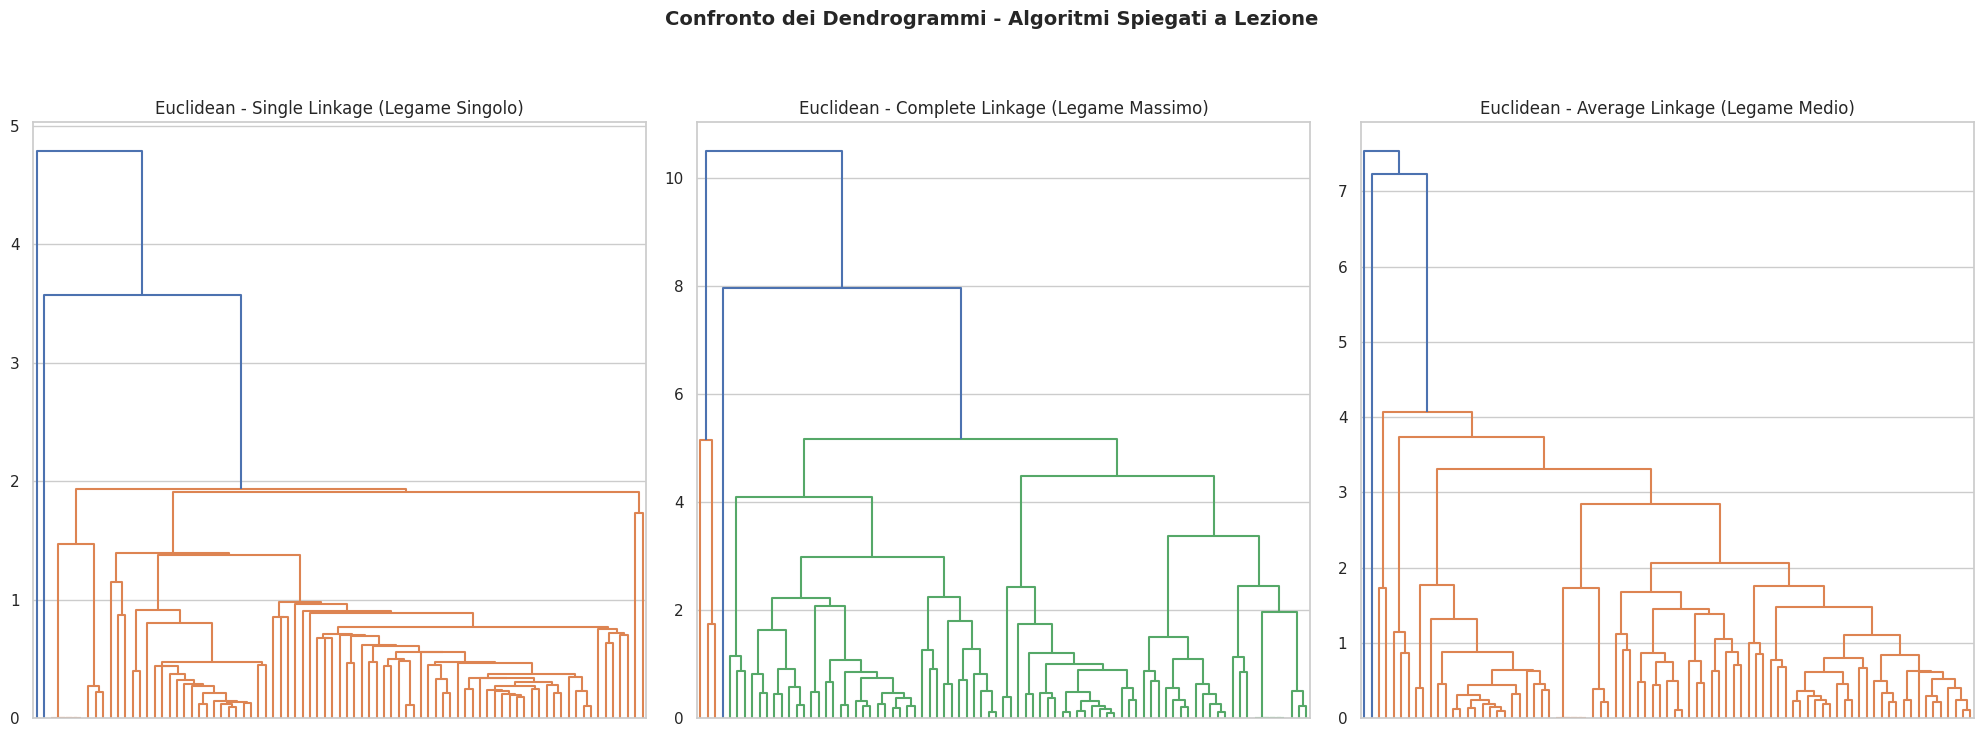

In [155]:
# 2. Calcolo delle distanze e dei Linkage (Corretto)
X_dist = pdist(X_scaled, metric='euclidean')

Z_s = linkage(X_dist, method='single')   # Corretto da 'simple' a 'single'
Z_c = linkage(X_dist, method='complete')
Z_a = linkage(X_dist, method='average')

# 3. Visualizzazione dei Dendrogrammi con etichette leggibili
fig, axs = plt.subplots(1, 3, figsize=(20, 7))

# Single
dendrogram(Z_s, ax=axs[0], no_labels = True, leaf_rotation=90, leaf_font_size=8)
axs[0].set_title("Euclidean - Single Linkage (Legame Singolo)")

# Complete
dendrogram(Z_c, ax=axs[1], no_labels = True, leaf_rotation=90, leaf_font_size=8)
axs[1].set_title("Euclidean - Complete Linkage (Legame Massimo)")

# Average
dendrogram(Z_a, ax=axs[2], no_labels = True, leaf_rotation=90, leaf_font_size=8)
axs[2].set_title("Euclidean - Average Linkage (Legame Medio)")

plt.suptitle("Confronto dei Dendrogrammi - Algoritmi Spiegati a Lezione", y=1.05, fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

Cophenetic Distances

In [156]:
c_single, _ = cophenet(Z_s, X_dist)
c_complete, _ = cophenet(Z_c, X_dist)
c_average, _ = cophenet(Z_a, X_dist)

print(f"Cophenetic Coeff.- Single Linkage:   {c_single:.4f}")
print(f"Cophenetic Coeff.- Complete Linkage: {c_complete:.4f}")
print(f"Cophenetic Coeff.- Average Linkage:  {c_average:.4f}")

Cophenetic Coeff.- Single Linkage:   0.8507
Cophenetic Coeff.- Complete Linkage: 0.7609
Cophenetic Coeff.- Average Linkage:  0.9295


We choose Average Linkage

When to cut? WSS and BSS minimizing

In [157]:
#Function
 
def compute_internal_measures(x, merges, k_values):
    wss_values = {}
    bss_values = {}

    overall_mean = np.mean(x, axis=0)  # Compute global mean

    for k in k_values:
        clustering = fcluster(merges, k, criterion='maxclust')
        # computes centroids for all clusters
        centroids = [np.mean(x[clustering==c],axis=0) for c in range(1,k+1)]
        cluster_sizes = [len(x[clustering==c]) for c in range(1,k+1)]
        # computes the euclidean distance between each point and each centroid
        D = cdist(x, centroids, 'euclidean')
        # find nearest centroid for each point
        cIdx = np.argmin(D,axis=1)
        # store the distances to the nearest centroid
        d = np.min(D,axis=1)

        # WSS
        wss = sum(d**2)

        # BSS
        bss = np.sum([size * np.sum((centroid - overall_mean) ** 2) for size, centroid in zip(cluster_sizes, centroids)])

        wss_values[k] = wss
        bss_values[k] = bss
    return wss_values,bss_values

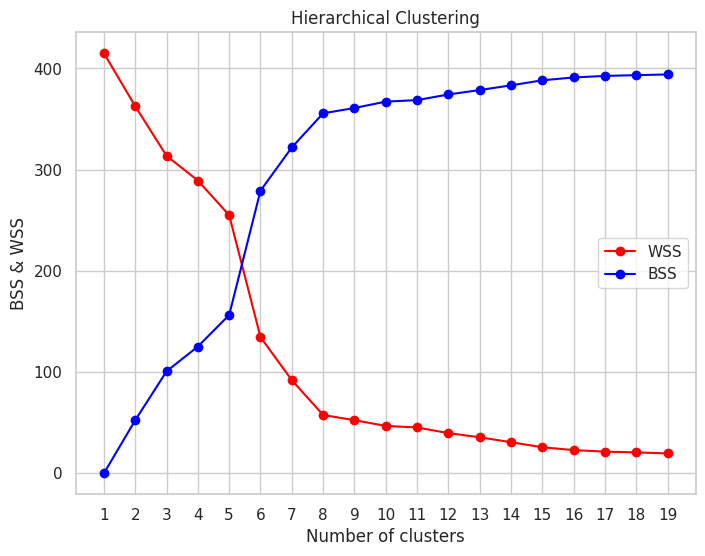

In [158]:
k_values = range(1,20)
wss_dict, bss_dict = compute_internal_measures(X_scaled, Z_a, k_values)
wss_values = [wss_dict[x] for x in range(1,20)]
bss_values = [bss_dict[x] for x in range(1,20)]
fig = plt.figure(figsize=(8,6))
font = {'family' : 'sans', 'size'   : 16}
plt.rc('font', **font)
plt.plot(k_values, wss_values, 'bo-', color='red', label='WSS')
plt.plot(k_values, bss_values, 'bo-', color='blue', label='BSS')
plt.grid(True)
plt.xlabel('Number of clusters')
plt.ylabel('BSS & WSS')
plt.xticks(k_values)
plt.legend()
plt.title('Hierarchical Clustering');

In [159]:
clustering = fcluster(Z_a, 5, criterion='maxclust')
print(pd.Series(clustering).value_counts())

3    76
2     3
1     2
4     1
5     1
Name: count, dtype: int64


In [160]:
clustering = fcluster(Z_a, 3, criterion='maxclust')
print(pd.Series(clustering).value_counts())

1    81
2     1
3     1
Name: count, dtype: int64


In [161]:
# Assegniamo l'array 'clustering' (generato con K=5 e Complete Linkage) come colonna del DataFrame
# Assicurati di aver generato 'clustering' usando Z_c (Complete Linkage) e k=5
df_cluster['cluster_completato'] = clustering

# Stampiamo le cause contenute in ciascun cluster
print("--- COMPOSIZIONE REALE DEI CLUSTER (Complete Linkage, K=5) ---\n")

for numero_cluster in sorted(df_cluster['cluster_completato'].unique()):
    # Estraiamo le cause appartenenti a quel blocco
    cause_nel_cluster = df_cluster[df_cluster['cluster_completato'] == numero_cluster].index.tolist()
    
    print(f"=========================================")
    print(f"CLUSTER {numero_cluster} ({len(cause_nel_cluster)} micro-cause)")
    print(f"=========================================")
    
    # Stampiamo tutte le cause del cluster (una per riga per leggerle bene)
    for c in cause_nel_cluster:
        print(f" • {c}")
    print("\n")

--- COMPOSIZIONE REALE DEI CLUSTER (Complete Linkage, K=5) ---

CLUSTER 1 (81 micro-cause)
 • [Conducente] Abbagliato
 • [Conducente] Anormale per ebbrezza da alcool
 • [Conducente] Attraversava imprudentemente il passaggio a livello
 • [Conducente] Frenava improvvisamente con conseguenza ai trasportati
 • [Conducente] Fuoriusciva dalla carreggiata investendo il pedone
 • [Conducente] Mancato uso di lenti correttive o apparecchi di protesi
 • [Conducente] Manovrava in retrocessione o conversione
 • [Conducente] Non dava la precedenza al pedone sugli appositi attraversamenti
 • [Conducente] Per aver superato i periodi di guida prescritti
 • [Conducente] Procedeva con guida distratta o andamento indeciso
 • [Conducente] Procedeva non in prossimità del margine destro della carreggiata
 • [Conducente] Si affiancava ad altri veicoli a due ruote irregolarmente
 • [Conducente] Sorpassava all'incrocio
 • [Conducente] Sorpassava irregolarmente a destra
 • [Conducente] Sorpassava un veicolo ferm

Chaining Effect, let's try with Complete

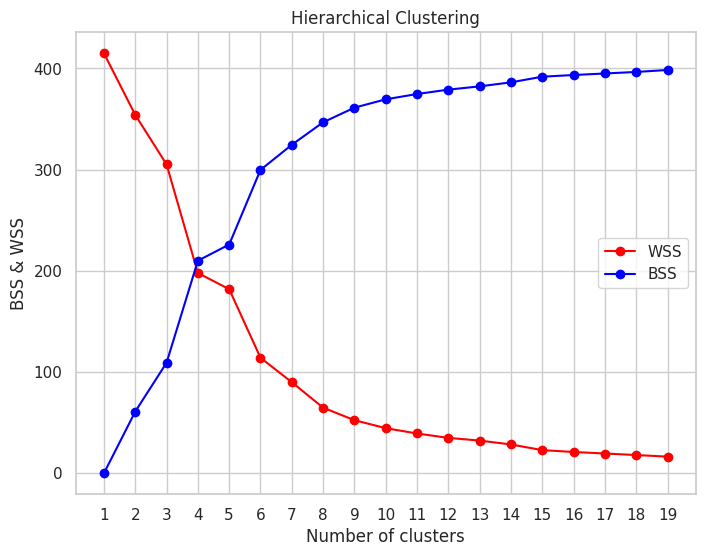

In [162]:
k_values = range(1,20)
wss_dict, bss_dict = compute_internal_measures(X_scaled, Z_c, k_values)
wss_values = [wss_dict[x] for x in range(1,20)]
bss_values = [bss_dict[x] for x in range(1,20)]
fig = plt.figure(figsize=(8,6))
font = {'family' : 'sans', 'size'   : 16}
plt.rc('font', **font)
plt.plot(k_values, wss_values, 'bo-', color='red', label='WSS')
plt.plot(k_values, bss_values, 'bo-', color='blue', label='BSS')
plt.grid(True)
plt.xlabel('Number of clusters')
plt.ylabel('BSS & WSS')
plt.xticks(k_values)
plt.legend()
plt.title('Hierarchical Clustering');

In [163]:
clustering = fcluster(Z_c, 3, criterion='maxclust')
print(pd.Series(clustering).value_counts())

2    79
1     3
3     1
Name: count, dtype: int64


In [164]:
clustering = fcluster(Z_c, 5, criterion='maxclust')
print(pd.Series(clustering).value_counts())

4    42
3    37
1     2
5     1
2     1
Name: count, dtype: int64


In [165]:
# Assegniamo l'array 'clustering' (generato con K=5 e Complete Linkage) come colonna del DataFrame
# Assicurati di aver generato 'clustering' usando Z_c (Complete Linkage) e k=5
df_cluster['cluster_completato'] = clustering

# Stampiamo le cause contenute in ciascun cluster
print("--- COMPOSIZIONE REALE DEI CLUSTER (Complete Linkage, K=5) ---\n")

for numero_cluster in sorted(df_cluster['cluster_completato'].unique()):
    # Estraiamo le cause appartenenti a quel blocco
    cause_nel_cluster = df_cluster[df_cluster['cluster_completato'] == numero_cluster].index.tolist()
    
    print(f"=========================================")
    print(f"CLUSTER {numero_cluster} ({len(cause_nel_cluster)} micro-cause)")
    print(f"=========================================")
    
    # Stampiamo tutte le cause del cluster (una per riga per leggerle bene)
    for c in cause_nel_cluster:
        print(f" • {c}")
    print("\n")

--- COMPOSIZIONE REALE DEI CLUSTER (Complete Linkage, K=5) ---

CLUSTER 1 (2 micro-cause)
 • [Conducente] per improvviso malore
 • [Contesto] Rottura degli organi di agganciamento dei rimorchi


CLUSTER 2 (1 micro-cause)
 • [Pedone] per improvviso malore


CLUSTER 3 (37 micro-cause)
 • [Conducente] Abbagliato
 • [Conducente] Anormale per ebbrezza da alcool
 • [Conducente] Procedeva con guida distratta o andamento indeciso
 • [Conducente] Procedeva non in prossimità del margine destro della carreggiata
 • [Conducente] Sorpassava all'incrocio
 • [Conducente] Sorpassava irregolarmente a destra
 • [Conducente] Svoltava a destra irregolarmente
 • [Conducente] Svoltava a sinistra irregolarmente
 • [Conducente] con eccesso di velocità
 • [Conducente] con le luci abbaglianti incrociando altri veicoli
 • [Conducente] contromano
 • [Conducente] in curva, su dosso o con insufficiente visibilità
 • [Conducente] irregolarmente per fermarsi o sostare
 • [Conducente] per condizioni morbose in atto
 •

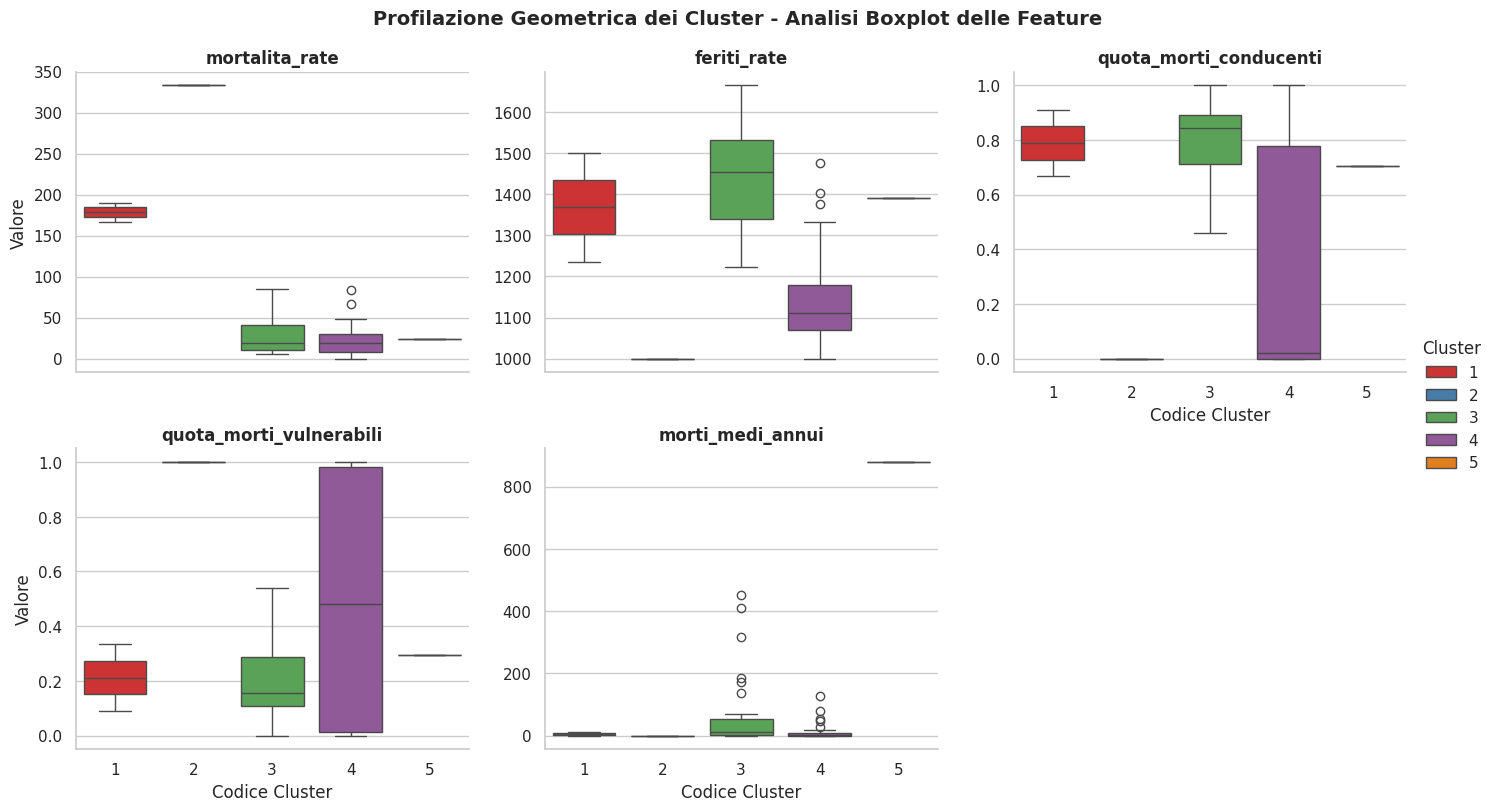

In [174]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definiamo qual è la colonna dove hai salvato i cluster
colonna_cluster = 'cluster_completato' 

# 2. Selezioniamo solo le 5 feature numeriche e la colonna del cluster
features_numeriche = ['mortalita_rate', 'feriti_rate', 'quota_morti_conducenti', 'quota_morti_vulnerabili', 'morti_medi_annui']
df_boxplot = df_cluster[features_numeriche + [colonna_cluster]].copy()

# 3. Portiamo 'causa' da indice a colonna e applichiamo il melt
df_melt = df_boxplot.reset_index().melt(
    id_vars=['causa', colonna_cluster], 
    value_vars=features_numeriche,
    var_name='Feature', 
    value_name='Valore'
)

# 4. Creiamo il FacetGrid dinamico
g = sns.FacetGrid(
    df_melt, 
    col="Feature", 
    sharey=False, 
    hue=colonna_cluster, 
    palette="Set1", 
    height=4, 
    aspect=1.2,
    col_wrap=3
)

# Mappiamo il boxplot rimuovendo il parametro alpha problematico
ordine_cluster = sorted(df_cluster[colonna_cluster].unique())
g.map(sns.boxplot, colonna_cluster, "Valore", order=ordine_cluster)

# Pulizia estetica dei grafici
g.add_legend(title="Cluster")
g.set_titles("{col_name}", weight='bold')
g.set_axis_labels("Codice Cluster", "Valore")

# Spostiamo il titolo globale verso l'alto
plt.suptitle("Profilazione Geometrica dei Cluster - Analisi Boxplot delle Feature", y=1.02, fontsize=14, weight='bold')

plt.show()

# 9. Regressione lineare come baseline

La regressione lineare viene usata come modello di riferimento, non come modello finale atteso. Serve a verificare quanto una struttura additiva riesca a spiegare il numero di morti usando variabili disponibili prima dell'esito, evitando leakage da colonne che sono componenti dirette dei morti totali.


In [ ]:
import statsmodels.formula.api as smf

model_df = cause_core.copy()
model_df = model_df[model_df['incidenti'] > 0].replace([np.inf, -np.inf], np.nan).copy()
model_df['log_incidenti'] = np.log1p(model_df['incidenti'])
model_df['post_covid'] = (model_df['anno'] >= 2020).astype(int)

ols_df = model_df[[
    'morti_totale', 'log_incidenti', 'feriti_totale',
    'feriti_per_1000_incidenti', 'quota_incidenti_anno_pct',
    'anno', 'macro_categoria'
]].dropna().copy()

ols = smf.ols(
    'morti_totale ~ log_incidenti + feriti_per_1000_incidenti + quota_incidenti_anno_pct + C(macro_categoria) + anno',
    data=ols_df
).fit(cov_type='HC3')
print(ols.summary())

ols_df['pred_ols'] = ols.predict(ols_df)
ols_df['resid_ols'] = ols_df['morti_totale'] - ols_df['pred_ols']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=ols_df, x='pred_ols', y='resid_ols', hue='macro_categoria', alpha=0.7, ax=axes[0])
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Residui OLS vs valori previsti')
axes[0].set_xlabel('Morti previsti')
axes[0].set_ylabel('Residuo')

sns.scatterplot(data=ols_df, x='log_incidenti', y='morti_totale', hue='macro_categoria', alpha=0.7, ax=axes[1])
axes[1].set_title('Mortalita osservata rispetto al volume incidenti')
axes[1].set_xlabel('log1p(incidenti)')
axes[1].set_ylabel('Morti totali')
plt.tight_layout()
plt.show()


## 10. Modelli di conteggio: Poisson e Negative Binomial

Per i decessi ha piu senso modellare un conteggio. L'offset `log(incidenti)` trasforma il modello in una stima del tasso di mortalita a parita di numero di incidenti.

In [167]:
import statsmodels.api as sm

poisson = smf.glm('morti_totale ~ quota_morti_pedoni_pct + quota_morti_trasportati_pct + C(macro_categoria) + C(anno)',
                  data=model_df,
                  family=sm.families.Poisson(),
                  offset=np.log(model_df['incidenti'])).fit()
print(poisson.summary())
print('Overdispersion ratio:', poisson.pearson_chi2 / poisson.df_resid)

nb = smf.glm('morti_totale ~ quota_morti_pedoni_pct + quota_morti_trasportati_pct + C(macro_categoria) + C(anno)',
             data=model_df,
             family=sm.families.NegativeBinomial(),
             offset=np.log(model_df['incidenti'])).fit()
print(nb.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           morti_totale   No. Observations:                  999
Model:                            GLM   Df Residuals:                      972
Model Family:                 Poisson   Df Model:                           26
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -8788.6
Date:                Wed, 17 Jun 2026   Deviance:                       13643.
Time:                        14:36:47   Pearson chi2:                 1.65e+04
No. Iterations:                    10   Pseudo R-squ. (CS):             0.9594
Covariance Type:            nonrobust                                         
                                                                                                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

## 11. Pipeline predittiva e importanza delle variabili

La pipeline confronta tre modelli in ordine crescente di flessibilita: Linear Regression, Lasso e Random Forest. Le feature sono scelte per evitare leakage: non vengono usate le componenti dei morti (`morti_conducenti`, `morti_trasportati`, `morti_pedoni`) ne quote calcolate direttamente sui morti quando il target e `morti_totale`.


In [ ]:
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

candidate_features = [
    'anno', 'incidenti', 'feriti_totale', 'feriti_per_1000_incidenti',
    'quota_incidenti_anno_pct', 'macro_categoria'
]
features_model = [c for c in candidate_features if c in model_df.columns]
target = 'morti_totale'

ml_df = model_df[features_model + [target]].replace([np.inf, -np.inf], np.nan).dropna().copy()
X = ml_df[features_model]
y = ml_df[target]

cat_features = [c for c in ['macro_categoria'] if c in features_model]
num_features = [c for c in features_model if c not in cat_features]

pre_linear = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])
pre_forest = ColumnTransformer([
    ('num', 'passthrough', num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {
    'Linear Regression': Pipeline([('pre', pre_linear), ('model', LinearRegression())]),
    'Lasso': Pipeline([('pre', pre_linear), ('model', LassoCV(cv=5, random_state=42, max_iter=50000))]),
    'Random Forest': Pipeline([('pre', pre_forest), ('model', RandomForestRegressor(
        n_estimators=600,
        random_state=42,
        min_samples_leaf=3,
        max_features='sqrt',
        n_jobs=-1
    ))])
}

results = []
fitted = {}
for name, pipe in pipelines.items():
    cv_scores = cross_validate(
        pipe, X, y, cv=cv,
        scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2'},
        n_jobs=-1
    )
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results.append({
        'modello': name,
        'MAE_cv': -cv_scores['test_mae'].mean(),
        'R2_cv': cv_scores['test_r2'].mean(),
        'MAE_test': mean_absolute_error(y_test, pred),
        'RMSE_test': root_mean_squared_error(y_test, pred),
        'R2_test': r2_score(y_test, pred)
    })
    fitted[name] = pipe

model_results = pd.DataFrame(results).sort_values(['MAE_test', 'MAE_cv'])
display(model_results)

feature_names = fitted['Linear Regression'].named_steps['pre'].get_feature_names_out()
coef_linear = pd.DataFrame({
    'feature': feature_names,
    'Linear Regression': fitted['Linear Regression'].named_steps['model'].coef_,
    'Lasso': fitted['Lasso'].named_steps['model'].coef_
})
coef_linear['abs_lasso'] = coef_linear['Lasso'].abs()
print('Coefficienti standardizzati dei modelli lineari:')
display(coef_linear.sort_values('abs_lasso', ascending=False).drop(columns='abs_lasso').head(20))

rf_pre = fitted['Random Forest'].named_steps['pre']
rf_feature_names = rf_pre.get_feature_names_out()
rf_model = fitted['Random Forest'].named_steps['model']
rf_importance = pd.DataFrame({
    'feature': rf_feature_names,
    'Random Forest importance': rf_model.feature_importances_
}).sort_values('Random Forest importance', ascending=False)
print('Importanza Random Forest basata sulla riduzione di impurita:')
display(rf_importance.head(20))

perm_rows = []
for name, pipe in fitted.items():
    perm = permutation_importance(pipe, X_test, y_test, n_repeats=20, random_state=42, scoring='neg_mean_absolute_error', n_jobs=-1)
    perm_rows.append(pd.DataFrame({
        'modello': name,
        'feature': X_test.columns,
        'importanza_permutation_MAE': perm.importances_mean
    }))

permutation_table = pd.concat(perm_rows, ignore_index=True)
print('Importanza per permutazione sulle feature originali:')
display(permutation_table.sort_values(['modello', 'importanza_permutation_MAE'], ascending=[True, False]))


## 12. Sintesi per proposte di miglioramento

Una proposta credibile dovrebbe distinguere tre priorita:

1. **Cause ad alto volume**: generano il maggior numero di incidenti e quindi hanno grande impatto sociale anche se il tasso di mortalita non e massimo.
2. **Cause ad alta letalita**: meno frequenti, ma con molti morti ogni 1.000 incidenti.
3. **Cause con vulnerabilita pedonale**: prioritarie per interventi su attraversamenti, velocita urbana, visibilita e separazione dei flussi.

Nel report finale conviene presentare una matrice volume-severita: asse x = incidenti, asse y = mortalita per 1.000 incidenti, colore = quota morti pedoni, dimensione = morti totali.

**Perche il modello migliore tende a funzionare meglio.**

Se Random Forest ottiene l'errore piu basso, il risultato e coerente con la natura dei dati: `morti_totale` e un conteggio, le distribuzioni sono sbilanciate, e l'effetto di `incidenti` e `feriti_totale` non e necessariamente una retta unica valida per tutte le macro-categorie. Una foresta puo usare soglie diverse per cause ad alto e basso volume e puo catturare interazioni implicite tra anno, macro-categoria, incidenti e feriti. Linear Regression resta una baseline utile ma rigida; Lasso migliora la parsimonia e riduce coefficienti poco informativi, ma resta lineare. La Random Forest e quindi piu adatta quando emergono non linearita, outlier e combinazioni di cause/categorie che modificano il rapporto tra esposizione e morti.


In [169]:
summary = (cause_core.groupby('causa', as_index=False)
           .agg(incidenti=('incidenti', 'sum'),
                morti=('morti_totale', 'sum'),
                feriti=('feriti_totale', 'sum')))
summary['mortalita_pool'] = summary['morti'] / summary['incidenti'].replace(0, np.nan) * 1000

summary = summary.merge(victim_profile[['causa', 'quota_pedoni_pct']], on='causa', how='left')
summary['quota_pedoni_pct'] = summary['quota_pedoni_pct'].fillna(0)
summary['priorita'] = np.select(
    [summary['incidenti'].ge(summary['incidenti'].quantile(.75)) & summary['mortalita_pool'].ge(summary['mortalita_pool'].median()),
     summary['mortalita_pool'].ge(summary['mortalita_pool'].quantile(.75)),
     summary['quota_pedoni_pct'].ge(50)],
    ['alto volume e severita', 'alta letalita', 'forte impatto pedoni'],
    default='monitoraggio'
)
display(summary.sort_values(['priorita', 'morti'], ascending=[True, False]).head(30))

plt.figure(figsize=(10, 7))
sizes = 40 + 500 * summary['morti'] / summary['morti'].max()
sc = plt.scatter(summary['incidenti'], summary['mortalita_pool'], s=sizes, c=summary['quota_pedoni_pct'], cmap='viridis', alpha=.7)
plt.xscale('log')
plt.xlabel('Incidenti 2007-2024, scala log')
plt.ylabel('Morti per 1.000 incidenti')
plt.title('Matrice volume-severita delle cause')
plt.colorbar(sc, label='Quota morti pedoni (%)')
plt.show()


KeyError: 'mortalita_pool'